# Annotate BANC Neurite Bundles

Query BANC tables (`codex_annotations`, `cell_info`) to find neurons of a specific hemilineage in a specific neuropil/side, then generate Neuroglancer states for bundle annotation.

In [6]:
from caveclient import CAVEclient
import pandas as pd
import numpy as np
import sys


#sys.path.insert(0, 'C:\Users\JHS\Documents\Python\project_folder_4B\BANC')
#sys.path.insert(0, 'C:C:\Users\JHS\Documents\Python\project_folder_4B\BANC')
#import annot8or
#from annot8_utils import split_pt_pos_str_lists
from nglui.statebuilder import ViewerState
import nglui.parser as parser

c:\Users\JHS\Documents\Python\cave_env\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [7]:
client = CAVEclient()
client.info.get_datastacks()

['minnie35_public_v0',
 'fanc_sandbox',
 'zheng_ca3',
 'flywire_fafb_sandbox',
 'fanc_production_mar2021',
 'mrgd',
 'pinky_sandbox',
 'minnie65_sandbox',
 'brain_and_nerve_cord',
 'flywire_fafb_public',
 'minnie65_public',
 'brain_and_nerve_cord_public']

In [8]:
# Jelly First time use: token to access BANC:
##save token in users cloudC:\Users\JHS\.cloudvolume\secrets\
##cave-secret.json
##in here: 
#{
 # "token": "PASTE_YOUR_TOKEN_HERE"
#}
from caveclient import CAVEclient
client = CAVEclient("brain_and_nerve_cord")
client.info.get_datastack_info()


{'aligned_volume': {'id': 9,
  'name': 'brain_and_nerve_cord',
  'display_name': 'BANC',
  'description': 'The BANC (said "the bank") is the Brain And Nerve Cord, a GridTape transmission electron microscopy dataset of a female adult Drosophila melanogaster\'s entire central nervous system. Visit https://banc.community for more information.',
  'image_source': 'precomputed://gs://seunglab_lee_fly_cns_001_alignment/aligned/v0'},
 'segmentation_source': 'graphene://https://cave.fanc-fly.com/segmentation/table/wclee_fly_cns_001',
 'skeleton_source': 'precomputed://https://cave.fanc-fly.com/skeletoncache/api/v1/brain_and_nerve_cord/precomputed/skeleton',
 'analysis_database': None,
 'viewer_site': 'https://spelunker.cave-explorer.org/',
 'synapse_table': 'synapses_v2',
 'soma_table': None,
 'local_server': 'https://cave.fanc-fly.com',
 'description': None,
 'viewer_resolution_x': 4.0,
 'viewer_resolution_y': 4.0,
 'viewer_resolution_z': 45.0,
 'proofreading_status_table': 'backbone_proofrea

In [15]:
dataset = 'brain_and_nerve_cord'
client = CAVEclient(dataset)
client.annotation.get_tables()

['peripheral_nerves',
 'neck_connective_y121000',
 'cell_ids',
 'neck_connective_y92500',
 'synapses_v3_mean_score',
 'codex_annotations',
 'pm_proofreading_statusonly_test',
 'pm_cell_info_test',
 'pm_proofreading_status_test',
 'haltere_sensory_afferents',
 'proofreading_notes',
 'synapses_v3_median_score',
 'leg_mn_nerve_reftable_v2',
 'leg_mn_neuropil_reftable_v2',
 'synapses_v2_nt_prediction_5',
 'leg_mn_cell_type_table_v0',
 'leg_mechanosensory_axons',
 'banc_fafb_nblast_v2',
 'legcs_axons',
 'cell_info2_test',
 'neck_mn_cell_type_table_v0',
 'banc_malecns_nblast',
 'banc_fafb_nblast',
 'neck_mn_neuropil_reftable_v0',
 'neck_mn_nerve_reftable_v0',
 'somas_v1a',
 'somas_v1b',
 'synapses_v1_regions_test',
 'wing_mn_cell_type_table_v0',
 'banc_hemibrain_nblast',
 'banc_fanc_nblast',
 'wing_mn_neuropil_reftable_v0',
 'banc_malecns_nblast_v2',
 'banc_manc_nblast',
 'banc_hemibrain_nblast_v2',
 'banc_fanc_nblast_v2',
 'backbone_proofread',
 'downstream_cs_axons',
 'synapses_v2',
 'wing

## Explore codex_annotations and cell_info schemas
Run these cells once to understand what columns and values are available for hemilineage queries.

### codex_annotations

In [5]:
# Inspect codex_annotations schema and sample data
codex_meta = client.annotation.get_table_metadata('codex_annotations')
print('codex_annotations metadata:')
print(codex_meta)
print()

codex_df = client.materialize.query_table('codex_annotations', limit=50)
print('Columns:', codex_df.columns.tolist())
print('Shape:', codex_df.shape)
codex_df.head(10)

codex_annotations metadata:
{'id': 54, 'schema_type': 'cell_type_reference', 'table_name': 'codex_annotations', 'valid': True, 'created': '2025-07-16T19:37:03.061831', 'deleted': None, 'user_id': '386', 'description': "[This table 'codex_annotations' will update the 'target_id' foreign_key when updates are made to the 'cell_representative_point' table] ", 'notice_text': None, 'reference_table': 'cell_representative_point', 'flat_segmentation_source': None, 'write_permission': 'PRIVATE', 'read_permission': 'PUBLIC', 'last_modified': '2026-05-21T00:00:00', 'voxel_resolution': [1.0, 1.0, 1.0]}



Columns: ['id', 'created', 'valid', 'target_id', 'classification_system', 'cell_type', 'id_ref', 'created_ref', 'valid_ref', 'pt_supervoxel_id', 'pt_root_id', 'pt_position']
Shape: (50, 12)


,id,created,valid,target_id,classification_system,cell_type,id_ref,created_ref,valid_ref,pt_supervoxel_id,pt_root_id,pt_position
0,1047290,2026-02-02 00:00:00+00:00,True,60883,sexually_dimorphic,isomorphic,60883,2026-04-13 00:00:00+00:00,True,73818050600380358,720575941513292754,"[209228, 154868, 182700]"
1,1047291,2026-02-02 00:00:00+00:00,True,60884,sexually_dimorphic,isomorphic,60884,2026-04-13 00:00:00+00:00,True,73888419411457212,720575941406774063,"[213364, 151176, 190485]"
2,1047292,2026-02-02 00:00:00+00:00,True,60885,sexually_dimorphic,isomorphic,60885,2026-04-13 00:00:00+00:00,True,74240056906676302,720575941489479118,"[260896, 131052, 177075]"
3,1047293,2026-02-02 00:00:00+00:00,True,60887,sexually_dimorphic,isomorphic,60887,2026-04-13 00:00:00+00:00,True,73677450618018986,720575941469470742,"[195708, 165724, 193590]"
4,1047294,2026-02-02 00:00:00+00:00,True,60889,sexually_dimorphic,isomorphic,60889,2026-04-13 00:00:00+00:00,True,74169756948902685,720575941666502131,"[252324, 139020, 185490]"
5,1047295,2026-02-02 00:00:00+00:00,True,60890,sexually_dimorphic,isomorphic,60890,2026-04-13 00:00:00+00:00,True,73888488197806506,720575941659878224,"[216284, 159672, 199080]"
6,1047296,2026-02-02 00:00:00+00:00,True,60892,sexually_dimorphic,isomorphic,60892,2026-04-13 00:00:00+00:00,True,74029156900077671,720575941479129507,"[230544, 155392, 195255]"
7,1047297,2026-02-02 00:00:00+00:00,True,60893,sexually_dimorphic,isomorphic,60893,2026-04-13 00:00:00+00:00,True,74029156899637195,720575941488760885,"[236852, 148972, 188055]"
8,1047298,2026-02-02 00:00:00+00:00,True,60894,sexually_dimorphic,isomorphic,60894,2026-04-13 00:00:00+00:00,True,74029156900022530,720575941584320134,"[231276, 152836, 194265]"
9,1047299,2026-02-02 00:00:00+00:00,True,60895,sexually_dimorphic,isomorphic,60895,2026-04-13 00:00:00+00:00,True,74029088180359438,720575941631212997,"[231616, 144228, 191340]"


In [6]:
codex_df.cell_type.unique()

<StringArray>
['isomorphic']
Length: 1, dtype: string

In [7]:
codex_df.classification_system.unique()

<StringArray>
['sexually_dimorphic']
Length: 1, dtype: string

### cell_info

In [8]:
# Inspect cell_info schema and sample data
cell_info_meta = client.annotation.get_table_metadata('cell_info')
print('cell_info metadata:')
print(cell_info_meta)
print()

cell_info_df = client.materialize.query_table('cell_info', limit=2000)
print('Columns:', cell_info_df.columns.tolist())
print('Shape:', cell_info_df.shape)
cell_info_df.head(10)

cell_info metadata:
{'id': 4, 'schema_type': 'bound_double_tag_user', 'table_name': 'cell_info__wclee_fly_cns_001', 'valid': True, 'created': '2023-10-30T00:00:01.188701', 'deleted': None, 'user_id': '4741', 'description': 'A general-purpose cell type / cell information table. Included are cell types (e.g. broad types like motor neuron, central neuron, sensory neuron, & glia, plus more specific subtypes of each of those), anatomical descriptions (e.g. ascending, descending, soma in brain, soma in VNC), and specific neuron identities (e.g. giant fiber, DNa01), and more – see https://banc.community/Annotations-(cell-types,-etc.) for a list of all annotations that can be found here. \n\nEach row of this table is a key-value pair, with the "tag2" column being the key (or parent node in the annotation tree) and the "tag" column being the actual annotation (or child node in the annotation tree). Example key-value pairs are "soma region"-"soma in VNC", "primary class"-"glia", "primary class"-

Columns: ['id', 'created', 'superceded_id', 'valid', 'tag', 'tag2', 'user_id', 'pt_supervoxel_id', 'pt_root_id', 'pt_position']
Shape: (2000, 10)


,id,created,superceded_id,valid,tag,tag2,user_id,pt_supervoxel_id,pt_root_id,pt_position
0,54,2023-11-11 17:35:32.081991+00:00,<NA>,True,descending,anterior-posterior projection pattern,2660,76071705571238495,720575941652633585,"[116797, 92500, 2956]"
1,55,2023-11-12 14:36:34.958330+00:00,<NA>,True,descending,anterior-posterior projection pattern,2660,76001336827081255,720575941545312005,"[115253, 92500, 2959]"
2,56,2023-11-12 16:36:38.929404+00:00,<NA>,True,descending,anterior-posterior projection pattern,2660,75930968083101983,720575941390623382,"[113199, 92500, 3040]"
3,58,2023-11-12 18:27:19.632643+00:00,<NA>,True,ascending,anterior-posterior projection pattern,2660,75930968082569810,720575941435998094,"[113276, 92500, 2847]"
4,59,2023-11-12 18:28:14.602559+00:00,<NA>,True,descending,anterior-posterior projection pattern,2660,75930968082496232,720575941626175643,"[113218, 92500, 2823]"
5,60,2023-11-12 18:40:10.759619+00:00,<NA>,True,descending,anterior-posterior projection pattern,2660,75930968082877277,720575941526955266,"[113827, 92500, 2961]"
6,61,2023-11-13 00:57:41.702534+00:00,<NA>,True,descending,anterior-posterior projection pattern,2660,75930968082675467,720575941508047639,"[113634, 92500, 2883]"
7,62,2023-11-13 16:01:53.117437+00:00,<NA>,True,ascending,anterior-posterior projection pattern,2660,76001336692337941,720575941449745333,"[116227, 92500, 2538]"
8,63,2023-11-13 16:02:51.785790+00:00,<NA>,True,ascending,anterior-posterior projection pattern,2660,76071705504320138,720575941627244396,"[118479, 92500, 2772]"
9,64,2023-11-13 16:04:02.741154+00:00,<NA>,True,descending,anterior-posterior projection pattern,2660,76071705504203138,720575941561655341,"[117318, 92500, 2738]"


In [9]:
cell_info_df.tag.unique()

<StringArray>
[            'descending',              'ascending',         'sensory neuron',
             'CNS neuron',             'unilateral',                  'DNx01',
            'giant fiber',             'soma in T2',             'soma in T1',
 'T1 “multinerve” neuron',      'hair plate neuron',           'soma on left',
          'soma on right']
Length: 13, dtype: string

In [10]:
# Check which columns contain hemilineage-like data
# Adjust column names below after inspecting the output above
for col in codex_df.columns:
    try:
        unique_vals = codex_df[col].nunique()
    except TypeError:
        unique_vals = codex_df[col].apply(tuple).nunique()
    print(f'{col}: {unique_vals} unique values')
    if unique_vals < 30:
        try:
            print(f'  Values: {codex_df[col].unique()}')
        except TypeError:
            print(f'  Values: {codex_df[col].apply(tuple).unique()}')

id: 50 unique values
created: 1 unique values
  Values: <DatetimeArray>
['2026-02-02 00:00:00+00:00']
Length: 1, dtype: datetime64[ns, UTC]
valid: 1 unique values
  Values: <BooleanArray>
[True]
Length: 1, dtype: boolean
target_id: 50 unique values
classification_system: 1 unique values
  Values: <StringArray>
['sexually_dimorphic']
Length: 1, dtype: string
cell_type: 1 unique values
  Values: <StringArray>
['isomorphic']
Length: 1, dtype: string
id_ref: 50 unique values
created_ref: 1 unique values
  Values: <DatetimeArray>
['2026-04-13 00:00:00+00:00']
Length: 1, dtype: datetime64[ns, UTC]
valid_ref: 1 unique values
  Values: <BooleanArray>
[True]
Length: 1, dtype: boolean
pt_supervoxel_id: 50 unique values
pt_root_id: 50 unique values
pt_position: 50 unique values


## Query neurons by hemilineage + neuropil/side
Set parameters below, then run to find matching neurons.

In [11]:
# --- Set query parameters ---
hemilineage = '04B'
side = 'right'
neuropil = 't2'  # Options: 't1', 't2', 't3' (mapped to 'soma in T1', etc. in cell_info)

# --- Query codex_annotations ---
# codex_annotations uses a long-format key-value schema:
#   classification_system = key (e.g. 'hemilineage', 'side', 'region')
#   cell_type = value (e.g. '12B', 'right', 'ventral_nerve_cord')
# Each neuron has multiple rows, one per classification_system.
# We query each filter separately, then intersect by pt_root_id.

# 1) Get all neurons with the target hemilineage
hl_df = client.materialize.query_table('codex_annotations',
    filter_equal_dict={'classification_system': 'hemilineage', 'cell_type': hemilineage})
print(f'Neurons with hemilineage={hemilineage}: {hl_df.shape[0]}')

# 2) Get all neurons on the target side
side_df = client.materialize.query_table('codex_annotations',
    filter_equal_dict={'classification_system': 'side', 'cell_type': side})
print(f'Neurons on {side} side: {side_df.shape[0]}')

# 3) Get all neurons in VNC (codex region level)
region_df = client.materialize.query_table('codex_annotations',
    filter_equal_dict={'classification_system': 'region', 'cell_type': 'ventral_nerve_cord'})
print(f'Neurons in VNC: {region_df.shape[0]}')

# 4) Get MANC match IDs
manc_id = client.materialize.query_table('codex_annotations',
    filter_equal_dict={'classification_system': 'manc_121_match_id'})
print(f'Neurons with MANC id: {manc_id.shape[0]}')

# 5) Get MANC cell types
manc_type = client.materialize.query_table('codex_annotations',
    filter_equal_dict={'classification_system': 'manc_121_cell_type'})
print(f'Neurons with MANC type: {manc_type.shape[0]}')

KeyboardInterrupt: 

In [ ]:
# # 3) Get all neurons in VNC (codex region level)
# pt_root_id_df = client.materialize.query_table('codex_annotations',
#     filter_equal_dict={'pt_root_id': 720575941532368106})
# # print(f'Neurons in VNC: {region_df.shape[0]}')


## Generate Neuroglancer state
Build a state showing the known neurons of this hemilineage/region so you can visually identify additional neurons in the same bundle.

## Import new annotations from Neuroglancer state
After annotating new neurons in Neuroglancer, paste the state URL below to import them.

In [16]:
#the above numebrs do nto make sense for 4B; lets try this
import pandas as pd

print("\n==========================================")
print("BANC 04B → MANC T2-LEFT MATCHING")
print("==========================================")

# ============================================================
# SETTINGS
# ============================================================

hemilineage = "04B"
side = "right"

# IMPORTANT:
# This is the side in BANC.
# Your MANC CSV already contains the T2-left population
# selected in R.

MANC_FILE = (
    r"C:\Users\JHS\Documents\Python\project_folder_4B"
    r"\Faculty_Statement\MANC_T2_04B_metadata.csv"
)


# ============================================================
# 1. GET ALL BANC 04B NEURONS
# ============================================================

print("\nSTEP 1: Getting BANC 04B neurons...")

hl_df = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system": "hemilineage",
        "cell_type": hemilineage
    }
)

print(
    f"✓ BANC {hemilineage}: "
    f"{hl_df['pt_root_id'].nunique()} neurons"
)


# ============================================================
# 2. GET BANC SIDE ANNOTATION
# ============================================================

print(f"\nSTEP 2: Getting BANC {side}-side neurons...")

side_df = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system": "side",
        "cell_type": side
    }
)

print(
    f"✓ BANC {side} side: "
    f"{side_df['pt_root_id'].nunique()} neurons"
)


# ============================================================
# 3. INTERSECT 04B + SIDE
# ============================================================

print(
    f"\nSTEP 3: Intersecting "
    f"{hemilineage} + {side}..."
)

bundle_neurons = hl_df[
    hl_df["pt_root_id"].isin(
        side_df["pt_root_id"]
    )
].copy()

print(
    f"✓ BANC {hemilineage} + {side}: "
    f"{bundle_neurons['pt_root_id'].nunique()} neurons"
)


# ============================================================
# 4. GET BANC → MANC MATCH IDS
# ============================================================

print("\nSTEP 4: Getting BANC → MANC matches...")

manc_id = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system": "manc_121_match_id"
    }
)

manc_id_lookup = (
    manc_id[
        ["pt_root_id", "cell_type"]
    ]
    .rename(
        columns={
            "cell_type": "manc_match_id"
        }
    )
)

bundle_neurons = bundle_neurons.merge(
    manc_id_lookup,
    on="pt_root_id",
    how="left"
)

print(
    "✓ BANC neurons with MANC match: "
    f"{bundle_neurons['manc_match_id'].notna().sum()} / "
    f"{len(bundle_neurons)}"
)


# ============================================================
# 5. GET BANC → MANC CELL TYPE
# ============================================================

print("\nSTEP 5: Getting matched MANC cell types...")

manc_type = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system": "manc_121_cell_type"
    }
)

manc_type_lookup = (
    manc_type[
        ["pt_root_id", "cell_type"]
    ]
    .rename(
        columns={
            "cell_type": "manc_type"
        }
    )
)

bundle_neurons = bundle_neurons.merge(
    manc_type_lookup,
    on="pt_root_id",
    how="left"
)

print(
    "✓ BANC neurons with MANC type: "
    f"{bundle_neurons['manc_type'].notna().sum()} / "
    f"{len(bundle_neurons)}"
)


# ============================================================
# 6. CONVERT BANC MANC-MATCH ID
#
# Example:
# id:11997 → 11997
# ============================================================

print("\nSTEP 6: Cleaning MANC body IDs...")

bundle_neurons["manc_bodyid"] = (
    bundle_neurons["manc_match_id"]
    .astype("string")
    .str.replace("id:", "", regex=False)
)

bundle_neurons["manc_bodyid"] = pd.to_numeric(
    bundle_neurons["manc_bodyid"],
    errors="coerce"
).astype("Int64")

print("✓ MANC body IDs converted to numeric values")


# ============================================================
# 7. LOAD YOUR MANC T2-LEFT 04B CSV
# ============================================================

print("\nSTEP 7: Loading MANC T2-left 04B metadata...")

manc_t2_04b = pd.read_csv(
    MANC_FILE
)

print("✓ MANC metadata loaded")
print(f"  Rows: {len(manc_t2_04b)}")
print(f"  Columns: {manc_t2_04b.columns.tolist()}")

# Ensure bodyid is numeric
manc_t2_04b["bodyid"] = pd.to_numeric(
    manc_t2_04b["bodyid"],
    errors="coerce"
).astype("Int64")

print(
    f"  Unique MANC body IDs: "
    f"{manc_t2_04b['bodyid'].nunique()}"
)


# ============================================================
# 8. KEEP ONLY BANC NEURONS MATCHING MANC T2-LEFT 04B
# ============================================================

print(
    "\nSTEP 8: Matching BANC neurons "
    "to MANC T2-left 04B..."
)

bundle_T2_04B = bundle_neurons[
    bundle_neurons["manc_bodyid"].isin(
        manc_t2_04b["bodyid"]
    )
].copy()


# ============================================================
# 9. FINAL RESULTS
# ============================================================

print("\n==========================================")
print("FINAL BANC 04B T2 POPULATION")
print("==========================================")

print(
    f"BANC {hemilineage} {side} neurons before T2 matching: "
    f"{bundle_neurons['pt_root_id'].nunique()}"
)

print(
    f"BANC neurons matched to MANC T2-left 04B: "
    f"{bundle_T2_04B['pt_root_id'].nunique()}"
)

print("\nMatched neurons:")

display(
    bundle_T2_04B[
        [
            "pt_root_id",
            "manc_bodyid",
            "manc_type"
        ]
    ].drop_duplicates()
)


BANC 04B → MANC T2-LEFT MATCHING

STEP 1: Getting BANC 04B neurons...
✓ BANC 04B: 478 neurons

STEP 2: Getting BANC right-side neurons...
✓ BANC right side: 82336 neurons

STEP 3: Intersecting 04B + right...
✓ BANC 04B + right: 239 neurons

STEP 4: Getting BANC → MANC matches...
✓ BANC neurons with MANC match: 238 / 239

STEP 5: Getting matched MANC cell types...
✓ BANC neurons with MANC type: 239 / 239

STEP 6: Cleaning MANC body IDs...
✓ MANC body IDs converted to numeric values

STEP 7: Loading MANC T2-left 04B metadata...
✓ MANC metadata loaded
  Rows: 187
  Columns: ['bodyid', 'post', 'pre', 'downstream', 'upstream', 'synweight', 'class', 'description', 'entryNerve', 'exitNerve', 'group', 'name', 'longTract', 'ntAcetylcholineProb', 'ntGabaProb', 'ntGlutamateProb', 'ntUnknownProb', 'origin', 'location', 'locationType', 'predictedNtProb', 'prefix', 'rootLocation', 'rootSide', 'statusLabel', 'subclass', 'synonyms', 'systematicType', 'target', 'transmission', 'type', 'vfbId', 'avgLoc

,pt_root_id,manc_bodyid,manc_type
0,720575941431071113,10179,AN04B001
2,720575941484965186,10394,AN04B003
4,720575941573524126,21147,IN04B071
20,720575941478288864,18335,IN04B081
36,720575941523083511,20416,IN04B087
...,...,...,...
211,720575941549465633,101038,IN04B061
212,720575941573493768,20556,IN04B097
213,720575941640954981,15537,IN04B027
214,720575941605268333,21464,IN04B084


In [17]:
#now get synapse data
# ============================================================
# BANC 04B T2-LEFT: GET OUTGOING SYNAPSES
# ============================================================

import pandas as pd

print("\n==========================================")
print("BANC 04B T2-LEFT OUTGOING SYNAPSES")
print("==========================================")

# ------------------------------------------------------------
# 1. SOURCE IDS
# ------------------------------------------------------------

source_ids = (
    bundle_T2_04B["pt_root_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

print(f"\nSource neurons: {len(source_ids)}")

if len(source_ids) == 0:
    raise ValueError("No source neurons found in bundle_T2_04B.")


# ------------------------------------------------------------
# 2. CHECK AVAILABLE SYNAPSE TABLES
# ------------------------------------------------------------

tables = client.materialize.get_tables()

possible_synapse_tables = [
    x for x in tables
    if "synapse" in x.lower()
]

print("\nAvailable synapse-related tables:")
for x in possible_synapse_tables:
    print(" ", x)


# ------------------------------------------------------------
# 3. USE SYNAPSES_V3 IF AVAILABLE,
#    OTHERWISE FALL BACK TO SYNAPSES_V2
# ------------------------------------------------------------

if "synapses_v3_mean_score" in tables:
    SYNAPSE_TABLE = "synapses_v3_mean_score"

elif "synapses_v3_median_score" in tables:
    SYNAPSE_TABLE = "synapses_v3_median_score"

elif "synapses_v2" in tables:
    SYNAPSE_TABLE = "synapses_v2"

else:
    raise ValueError(
        "Could not identify a BANC synapse table. "
        "Look at the synapse-related table names printed above."
    )

print(f"\nUsing synapse table: {SYNAPSE_TABLE}")


# ------------------------------------------------------------
# 4. INSPECT TABLE COLUMNS FIRST
# ------------------------------------------------------------

syn_sample = client.materialize.query_table(
    SYNAPSE_TABLE,
    limit=5
)

print("\nSynapse table columns:")
print(syn_sample.columns.tolist())

display(syn_sample.head())


BANC 04B T2-LEFT OUTGOING SYNAPSES

Source neurons: 77

Available synapse-related tables:
  synapses_v3_mean_score
  synapses_v3_median_score
  synapses_v2_nt_prediction_5
  synapses_v1_regions_test
  synapses_v2
  synapses_v1
  synapses_v3

Using synapse table: synapses_v3_mean_score



Synapse table columns:
['id', 'created', 'tag', 'valid', 'target_id', 'value', 'id_ref', 'created_ref', 'valid_ref', 'size', 'pre_pt_supervoxel_id', 'pre_pt_root_id', 'post_pt_supervoxel_id', 'post_pt_root_id', 'pre_pt_position', 'post_pt_position', 'ctr_pt_position']


,id,created,tag,valid,target_id,value,id_ref,created_ref,valid_ref,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position
0,11167001977907,2026-04-11 05:36:28.761656+00:00,<NA>,True,11167001977907,0.189703,11167001977907,2026-04-09 09:53:15.140037+00:00,True,54.0,73466343579815698,720575941455017709,73466343579777969,720575940579747238,"[10403, 10621, 1077]","[10405, 10617, 1073]","[10405, 10620, 1074]"
1,11167002764378,2026-04-11 05:36:28.761656+00:00,<NA>,True,11167002764378,0.116474,11167002764378,2026-04-09 09:53:15.140037+00:00,True,47.0,73466343579870443,720575941482539614,73466343579878340,720575940608090756,"[10392, 10716, 1110]","[10404, 10714, 1113]","[10403, 10713, 1113]"
2,11167002879013,2026-04-11 05:36:28.761656+00:00,<NA>,True,11167002879013,0.109619,11167002879013,2026-04-09 09:53:15.140037+00:00,True,50.0,73466343579738262,720575941513558574,73466343579746306,720575940579379878,"[10392, 10728, 1060]","[10402, 10734, 1061]","[10404, 10737, 1063]"
3,11168073679908,2026-04-11 05:36:28.761656+00:00,<NA>,True,11168073679908,0.132048,11168073679908,2026-04-09 09:53:15.140037+00:00,True,59.0,73466343579707440,720575941559151070,73466343579739598,720575940579357350,"[10399, 10377, 1057]","[10406, 10373, 1061]","[10405, 10374, 1060]"
4,11168075572259,2026-04-11 05:36:28.761656+00:00,<NA>,True,11168075572259,0.12281,11168075572259,2026-04-09 09:53:15.140037+00:00,True,26.0,73466343579743077,720575941538916840,73466343579727057,720575941478393908,"[10400, 10601, 1060]","[10400, 10602, 1057]","[10404, 10604, 1058]"


In [18]:
#now we filder the synapses and only find the targets for my 4B NOI

## ============================================================
# BANC 04B T2: EXTRACT OUTGOING SYNAPSES
# ============================================================

import pandas as pd

print("\n==========================================")
print("BANC 04B T2 OUTGOING SYNAPSES")
print("==========================================")

# ============================================================
# 1. GET SOURCE ROOT IDS
# ============================================================

source_ids = (
    bundle_T2_04B["pt_root_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

print(f"\nSource neurons: {len(source_ids)}")

if len(source_ids) == 0:
    raise ValueError(
        "No source neurons found in bundle_T2_04B."
    )


# ============================================================
# 2. QUERY OUTGOING SYNAPSES
#
# Use CAVE's dedicated synapse_query()
# rather than query_table().
# ============================================================

print("\nQuerying outgoing BANC synapses...")

syn_df = client.materialize.synapse_query(
    pre_ids=source_ids,
    remove_autapses=True,
    include_zeros=False
)

print("✓ Synapse query complete")

print(
    f"Individual synapses retrieved: "
    f"{len(syn_df):,}"
)


# ============================================================
# 3. CHECK RETURNED COLUMNS
# ============================================================

print("\nReturned columns:")
print(syn_df.columns.tolist())

print(
    f"\nUnique source neurons represented: "
    f"{syn_df['pre_pt_root_id'].nunique()}"
)

print(
    f"Unique downstream neurons: "
    f"{syn_df['post_pt_root_id'].nunique()}"
)


# ============================================================
# 4. COLLAPSE INDIVIDUAL SYNAPSES INTO
#    SOURCE -> TARGET SYNAPSE COUNTS
# ============================================================

connections = (
    syn_df
    .groupby(
        [
            "pre_pt_root_id",
            "post_pt_root_id"
        ]
    )
    .size()
    .reset_index(
        name="synapses"
    )
)

print(
    f"\nNeuron-to-neuron connections: "
    f"{len(connections):,}"
)


# ============================================================
# 5. SHOW STRONGEST CONNECTIONS
# ============================================================

print("\nStrongest outgoing connections:")

display(
    connections
    .sort_values(
        "synapses",
        ascending=False
    )
    .head(30)
)


BANC 04B T2 OUTGOING SYNAPSES

Source neurons: 77

Querying outgoing BANC synapses...
✓ Synapse query complete
Individual synapses retrieved: 188,241

Returned columns:
['id', 'created', 'superceded_id', 'valid', 'size', 'pre_pt_supervoxel_id', 'pre_pt_root_id', 'post_pt_supervoxel_id', 'post_pt_root_id', 'pre_pt_position', 'post_pt_position', 'ctr_pt_position']

Unique source neurons represented: 77
Unique downstream neurons: 122722

Neuron-to-neuron connections: 139,910

Strongest outgoing connections:


,pre_pt_root_id,post_pt_root_id,synapses
53111,720575941484965186,720575941431258721,171
54264,720575941484965186,720575941523371339,152
77354,720575941539464317,720575941462656467,143
129053,720575941625963419,720575941563920999,107
54983,720575941484965186,720575941593505387,106
17355,720575941431071113,720575941593843589,103
53826,720575941484965186,720575941487951757,98
17248,720575941431071113,720575941577820086,97
83864,720575941549269565,720575941480138976,97
14345,720575941431071113,720575941404752752,94


In [ ]:
# ============================================================
# COLLAPSE INDIVIDUAL SYNAPSES INTO CONNECTION COUNTS
# ============================================================

connections = (
    syn_df
    .groupby(
        [
            "pre_pt_root_id",
            "post_pt_root_id"
        ]
    )
    
    .size()
    .reset_index(
        name="synapses"
    )
)

print(
    f"Neuron-to-neuron connections: "
    f"{len(connections):,}"
)

print("\nStrongest connections:")

display(
    connections
    .sort_values(
        "synapses",
        ascending=False
    )
    .head(30)
)

Neuron-to-neuron connections: 139,910

Strongest connections:


,pre_pt_root_id,post_pt_root_id,synapses
53111,720575941484965186,720575941431258721,171
54264,720575941484965186,720575941523371339,152
77354,720575941539464317,720575941462656467,143
129053,720575941625963419,720575941563920999,107
54983,720575941484965186,720575941593505387,106
17355,720575941431071113,720575941593843589,103
53826,720575941484965186,720575941487951757,98
17248,720575941431071113,720575941577820086,97
83864,720575941549269565,720575941480138976,97
14345,720575941431071113,720575941404752752,94


In [19]:
#annotate both the source and downstream target BANC neurons using the Codex/MANC cell-type annotations.
# ============================================================
# ANNOTATE BANC CONNECTIONS WITH MANC CELL TYPES
# ============================================================

import pandas as pd

print("\n==========================================")
print("ANNOTATING BANC CONNECTIONS")
print("==========================================")

# ============================================================
# 1. GET MANC CELL-TYPE ANNOTATIONS
# ============================================================

print("\nSTEP 1: Loading MANC cell-type annotations...")

manc_types = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system": "manc_121_cell_type"
    }
)

print(
    f"✓ Retrieved {manc_types['pt_root_id'].nunique():,} "
    "annotated BANC neurons"
)


# ============================================================
# 2. CREATE SIMPLE ROOT-ID -> TYPE LOOKUP
# ============================================================

type_lookup = (
    manc_types[
        ["pt_root_id", "cell_type"]
    ]
    .drop_duplicates(subset="pt_root_id")
)

print(f"✓ Type lookup contains {len(type_lookup):,} neurons")


# ============================================================
# 3. ADD SOURCE TYPE
# ============================================================

source_lookup = type_lookup.rename(
    columns={
        "pt_root_id": "pre_pt_root_id",
        "cell_type": "source_type"
    }
)

results = connections.merge(
    source_lookup,
    on="pre_pt_root_id",
    how="left"
)

print(
    f"\nSources with MANC type: "
    f"{results['source_type'].notna().sum():,} / "
    f"{len(results):,} connections"
)


# ============================================================
# 4. ADD TARGET TYPE
# ============================================================

target_lookup = type_lookup.rename(
    columns={
        "pt_root_id": "post_pt_root_id",
        "cell_type": "target_type"
    }
)

results = results.merge(
    target_lookup,
    on="post_pt_root_id",
    how="left"
)

print(
    f"Targets with MANC type: "
    f"{results['target_type'].notna().sum():,} / "
    f"{len(results):,} connections"
)


# ============================================================
# 5. RENAME IDS TO MATCH OUR 7B FORMAT
# ============================================================

results = results.rename(
    columns={
        "pre_pt_root_id": "source_id",
        "post_pt_root_id": "target_id"
    }
)


# ============================================================
# 6. REORDER COLUMNS
# ============================================================

results = results[
    [
        "source_id",
        "source_type",
        "target_id",
        "target_type",
        "synapses"
    ]
]


# ============================================================
# 7. SUMMARY
# ============================================================

print("\n==========================================")
print("FINAL CONNECTIVITY TABLE")
print("==========================================")

print(
    f"Source neurons: "
    f"{results['source_id'].nunique()}"
)

print(
    f"Source types: "
    f"{results['source_type'].nunique()}"
)

print(
    f"Target neurons: "
    f"{results['target_id'].nunique()}"
)

print(
    f"Annotated target types: "
    f"{results['target_type'].nunique()}"
)

print(
    f"Connections with target-type annotation: "
    f"{results['target_type'].notna().sum():,} / "
    f"{len(results):,}"
)


# ============================================================
# 8. SHOW STRONGEST CONNECTIONS
# ============================================================

print("\nStrongest annotated connections:")

display(
    results[
        results["target_type"].notna()
    ]
    .sort_values(
        "synapses",
        ascending=False
    )
    .head(30)
)


# ============================================================
# 9. SAVE
# ============================================================

output_file = (
    r"C:\Users\JHS\Documents\Python\project_folder_4B"
    r"\Faculty_Statement\BANC_04B_T2_connectivity.csv"
)

results.to_csv(
    output_file,
    index=False
)

print("\n✓ Saved connectivity table:")
print(output_file)


ANNOTATING BANC CONNECTIONS

STEP 1: Loading MANC cell-type annotations...
✓ Retrieved 24,249 annotated BANC neurons
✓ Type lookup contains 24,249 neurons

Sources with MANC type: 139,910 / 139,910 connections
Targets with MANC type: 13,946 / 139,910 connections

FINAL CONNECTIVITY TABLE
Source neurons: 77
Source types: 43
Target neurons: 122722
Annotated target types: 1705
Connections with target-type annotation: 13,946 / 139,910

Strongest annotated connections:


,source_id,source_type,target_id,target_type,synapses
77354,720575941539464317,IN04B008,720575941462656467,IN19A019,143
129053,720575941625963419,IN04B006,720575941563920999,IN02A010,107
54983,720575941484965186,AN04B003,720575941593505387,DNnt017,106
53826,720575941484965186,AN04B003,720575941487951757,DNxn152,98
17248,720575941431071113,AN04B001,720575941577820086,IN13B005,97
83864,720575941549269565,IN04B081,720575941480138976,Ti extensor MN,97
14345,720575941431071113,AN04B001,720575941404752752,IN12B005,94
41527,720575941478288864,IN04B081,720575941480138976,Ti extensor MN,88
56139,720575941486871248,IN04B074,720575941480138976,Ti extensor MN,88
67612,720575941517281708,AN04B023,720575941438445330,DNxn175,88



✓ Saved connectivity table:
C:\Users\JHS\Documents\Python\project_folder_4B\Faculty_Statement\BANC_04B_T2_connectivity.csv


# now we make the plots


04B CONNECTIVITY HEATMAP
>=10 SYNAPSES PER SOURCE -> TARGET TYPE
ROWS CLUSTERED USING ALL RETAINED TARGETS

Initial data:
  Connections: 13,946
  Source neurons: 77
  Source types: 43
  Target neurons: 3064
  Target types: 1705

After collapsing targets by target_type:
  Source -> target-type connections: 11,469

Applied >= 10 synapse cutoff at source-neuron -> target-type level
  Connections retained: 822 / 11,469
  Source neurons retained: 77
  Target types retained: 326

Connectivity matrix: 77 neurons x 326 target types

Normalized matrix: 77 neurons x 326 target types
  Row-sum range: 1.000 - 1.000

Clustering neurons using ALL retained downstream target types...
✓ Row clustering complete

Selected top 25 target types for display

Clustering displayed target types...
✓ Column clustering complete

Final display matrix: 77 neurons x 25 displayed targets

90th percentile color cap: 0.3482

Creating figure...


PermissionError: [Errno 13] Permission denied: '04B_connectivity_min10syn_allTargetsRowCluster_columnCluster_90pct.pdf'

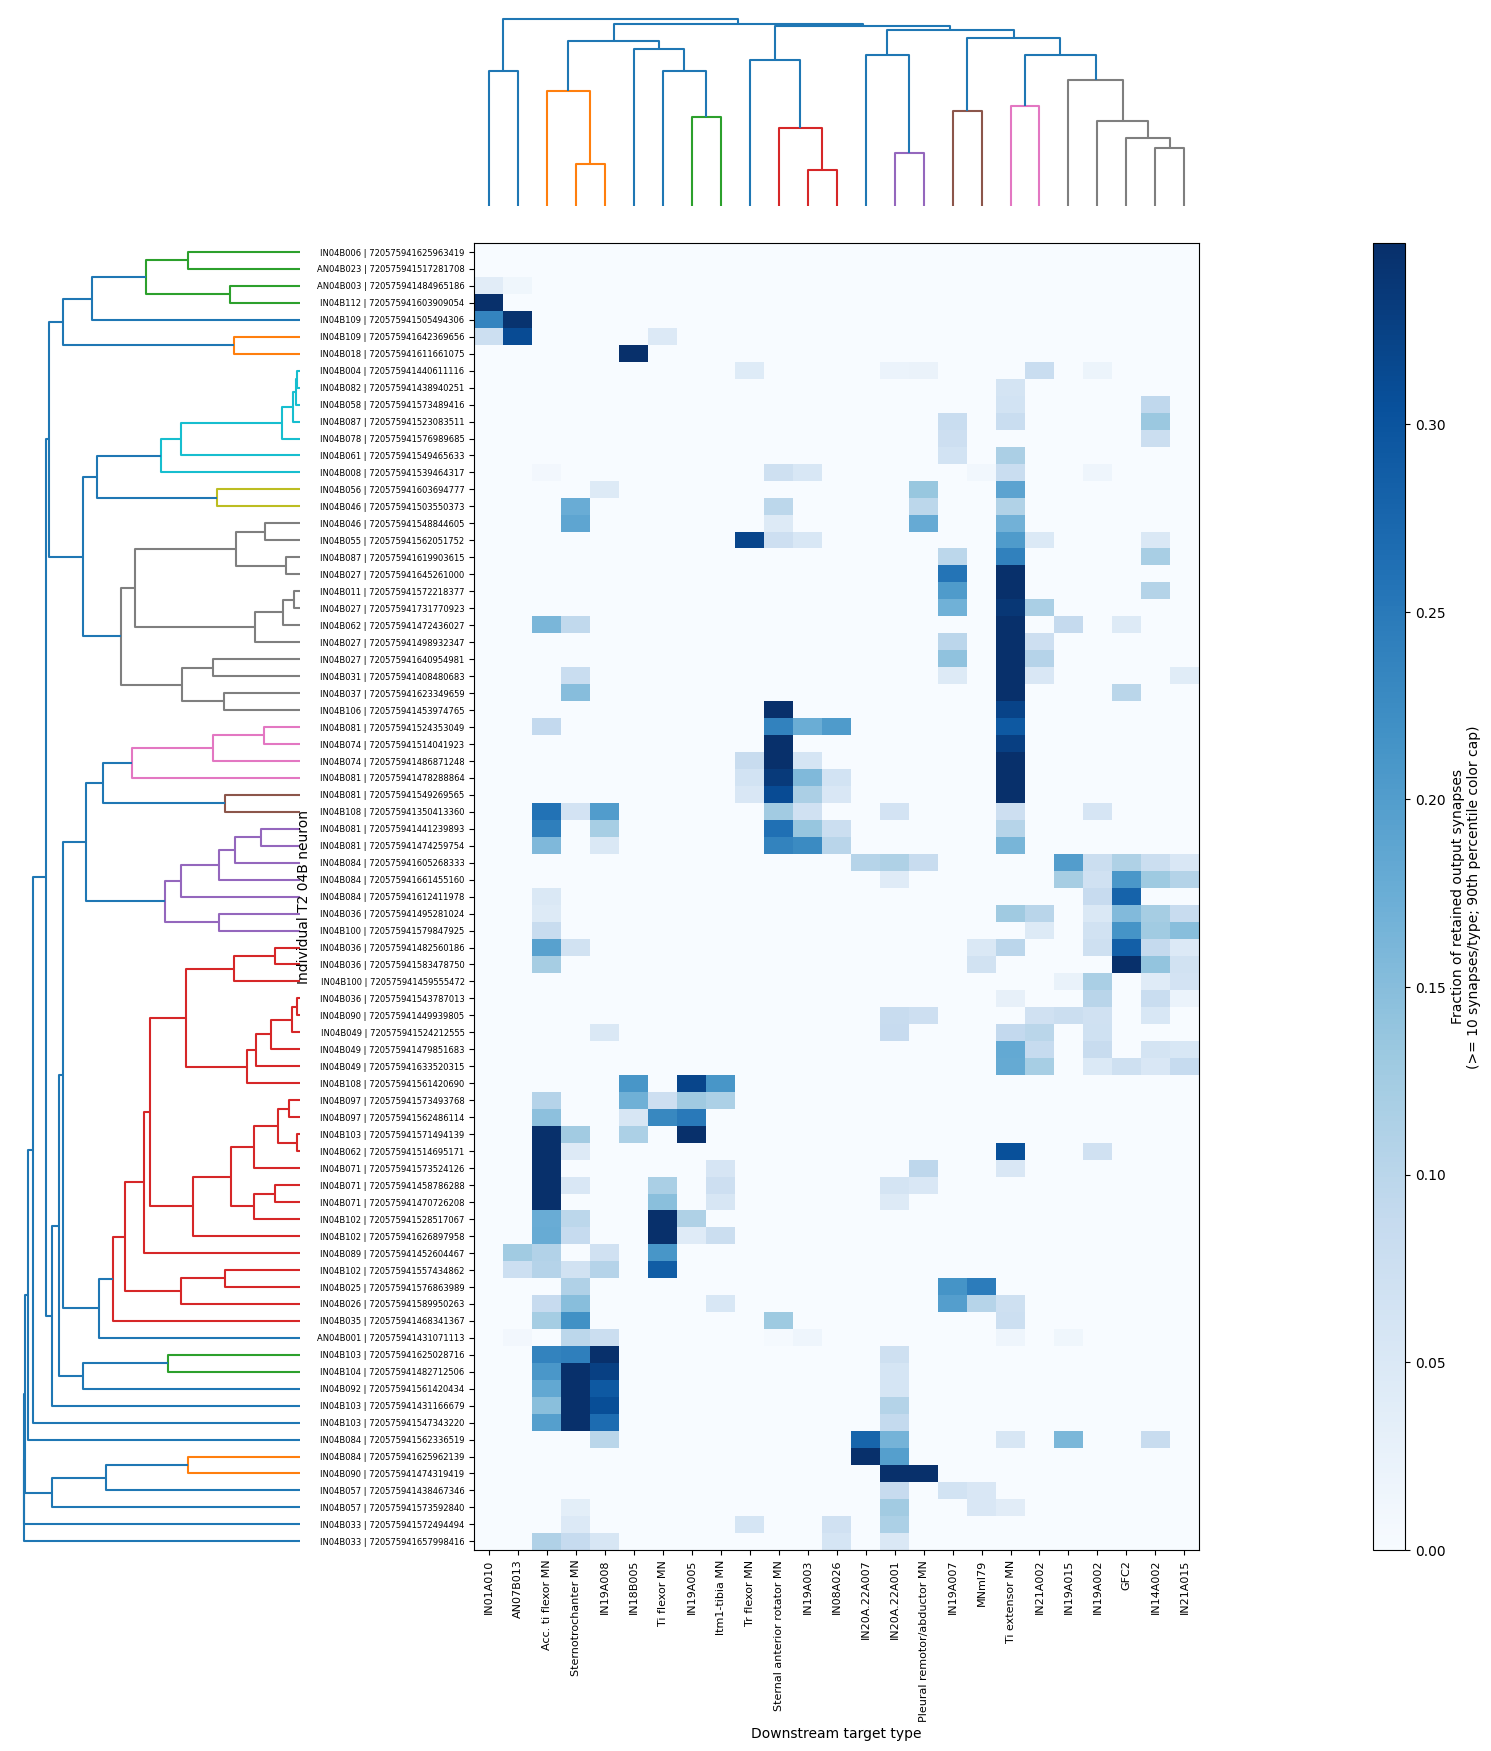

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist

print("\n==========================================")
print("04B CONNECTIVITY HEATMAP")
print(">=10 SYNAPSES PER SOURCE -> TARGET TYPE")
print("ROWS CLUSTERED USING ALL RETAINED TARGETS")
print("==========================================")

# ============================================================
# SETTINGS
# ============================================================

MIN_SYNAPSES = 10
NUMBER_OF_TARGETS = 25
PERCENTILE_CAP = 90


# ============================================================
# 1. CLEAN RESULTS
# ============================================================

df = results.dropna(
    subset=[
        "source_id",
        "source_type",
        "target_type",
        "synapses"
    ]
).copy()

print("\nInitial data:")
print(f"  Connections: {len(df):,}")
print(f"  Source neurons: {df['source_id'].nunique()}")
print(f"  Source types: {df['source_type'].nunique()}")
print(f"  Target neurons: {df['target_id'].nunique()}")
print(f"  Target types: {df['target_type'].nunique()}")


# ============================================================
# 2. COLLAPSE INDIVIDUAL TARGET NEURONS INTO TARGET TYPES
#
# Example:
# source neuron A -> 3 different IN19A008 neurons
# becomes:
# source neuron A -> IN19A008 = summed synapses
# ============================================================

grouped = (
    df.groupby(
        [
            "source_id",
            "source_type",
            "target_type"
        ],
        as_index=False
    )["synapses"]
    .sum()
)

print("\nAfter collapsing targets by target_type:")
print(f"  Source -> target-type connections: {len(grouped):,}")


# ============================================================
# 3. FILTER WEAK CONNECTIONS
#
# IMPORTANT:
# Threshold is applied AFTER collapsing by target type.
# So >=10 means:
# one source neuron makes >=10 total synapses onto that type.
# ============================================================

before_filter = len(grouped)

grouped = grouped[
    grouped["synapses"] >= MIN_SYNAPSES
].copy()

print(
    f"\nApplied >= {MIN_SYNAPSES} synapse cutoff "
    "at source-neuron -> target-type level"
)

print(
    f"  Connections retained: "
    f"{len(grouped):,} / {before_filter:,}"
)

print(
    f"  Source neurons retained: "
    f"{grouped['source_id'].nunique()}"
)

print(
    f"  Target types retained: "
    f"{grouped['target_type'].nunique()}"
)


# ============================================================
# 4. BUILD SOURCE-NEURON x TARGET-TYPE MATRIX
# ============================================================

matrix = grouped.pivot_table(
    index=[
        "source_id",
        "source_type"
    ],
    columns="target_type",
    values="synapses",
    aggfunc="sum",
    fill_value=0
)

print(
    f"\nConnectivity matrix: "
    f"{matrix.shape[0]} neurons x "
    f"{matrix.shape[1]} target types"
)


# ============================================================
# 5. NORMALIZE EACH SOURCE NEURON
#
# Each row sums to 1.
# Value = fraction of retained output synapses going to target type.
# ============================================================

normalized = matrix.div(
    matrix.sum(axis=1),
    axis=0
).fillna(0)

normalized = (
    normalized
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Remove empty rows
row_norms = np.linalg.norm(
    normalized.values,
    axis=1
)

normalized = normalized.loc[
    row_norms > 0
]

# Remove empty columns
col_norms = np.linalg.norm(
    normalized.values,
    axis=0
)

normalized = normalized.loc[
    :,
    col_norms > 0
]

print(
    f"\nNormalized matrix: "
    f"{normalized.shape[0]} neurons x "
    f"{normalized.shape[1]} target types"
)

row_sums = normalized.sum(axis=1)

print(
    f"  Row-sum range: "
    f"{row_sums.min():.3f} - "
    f"{row_sums.max():.3f}"
)


# ============================================================
# 6. CLUSTER ROWS USING ALL RETAINED TARGET TYPES
#
# This is the main biological clustering.
# It is NOT based only on the 25 displayed targets.
# ============================================================

print(
    "\nClustering neurons using ALL retained "
    "downstream target types..."
)

row_distance = pdist(
    normalized.values,
    metric="cosine"
)

if not np.isfinite(row_distance).all():
    raise ValueError(
        "Row cosine-distance matrix contains "
        "non-finite values."
    )

Z_rows = linkage(
    row_distance,
    method="average"
)

row_order = leaves_list(
    Z_rows
)

print("✓ Row clustering complete")


# ============================================================
# 7. SELECT TOP TARGET TYPES FOR DISPLAY ONLY
#
# This does NOT affect row clustering.
# ============================================================

top_targets = (
    normalized.sum(axis=0)
    .sort_values(ascending=False)
    .head(NUMBER_OF_TARGETS)
    .index
)

display_matrix = normalized.loc[
    :,
    top_targets
].copy()

print(
    f"\nSelected top {display_matrix.shape[1]} "
    "target types for display"
)


# ============================================================
# 8. CLUSTER DISPLAYED COLUMNS ONLY
#
# This changes only left-to-right target order.
# ============================================================

print("\nClustering displayed target types...")

display_col_norms = np.linalg.norm(
    display_matrix.values,
    axis=0
)

display_matrix = display_matrix.loc[
    :,
    display_col_norms > 0
]

column_distance = pdist(
    display_matrix.T.values,
    metric="cosine"
)

if not np.isfinite(column_distance).all():
    raise ValueError(
        "Column cosine-distance matrix contains "
        "non-finite values."
    )

Z_columns = linkage(
    column_distance,
    method="average"
)

column_order = leaves_list(
    Z_columns
)

print("✓ Column clustering complete")


# ============================================================
# 9. APPLY ROW + COLUMN ORDER
# ============================================================

plot_matrix = display_matrix.iloc[
    row_order,
    column_order
]

print(
    f"\nFinal display matrix: "
    f"{plot_matrix.shape[0]} neurons x "
    f"{plot_matrix.shape[1]} displayed targets"
)


# ============================================================
# 10. COLOR CONTRAST
#
# Cap at 90th percentile of non-zero displayed values.
# ============================================================

nonzero_values = plot_matrix.values[
    plot_matrix.values > 0
]

if len(nonzero_values) == 0:
    raise ValueError(
        "No non-zero connectivity values remain."
    )

vmax_cap = np.percentile(
    nonzero_values,
    PERCENTILE_CAP
)

print(
    f"\n{PERCENTILE_CAP}th percentile "
    f"color cap: {vmax_cap:.4f}"
)


# ============================================================
# 11. CREATE ROW LABELS
# ============================================================

row_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type
    in plot_matrix.index
]


# ============================================================
# 12. FIGURE LAYOUT
#
#                COLUMN DENDROGRAM
#
# ROW DENDRO     HEATMAP              COLORBAR
#
# Colorbar gets its own column so the top dendrogram
# aligns exactly with the heatmap.
# ============================================================

print("\nCreating figure...")

fig = plt.figure(
    figsize=(18, 20)
)

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[
        3.2,   # row dendrogram
        8,     # heatmap
        0.35   # colorbar
    ],
    height_ratios=[
        1.2,   # column dendrogram
        8      # heatmap
    ],
    wspace=0.50,
    hspace=0.05
)


# ============================================================
# 13. COLUMN DENDROGRAM
# ============================================================

ax_col_dendro = fig.add_subplot(
    gs[0, 1]
)

dendrogram(
    Z_columns,
    orientation="top",
    no_labels=True,
    ax=ax_col_dendro
)

ax_col_dendro.set_xticks([])
ax_col_dendro.set_yticks([])

for spine in ax_col_dendro.spines.values():
    spine.set_visible(False)


# ============================================================
# 14. ROW DENDROGRAM
#
# Derived from ALL retained target types.
# ============================================================

ax_row_dendro = fig.add_subplot(
    gs[1, 0]
)

dendrogram(
    Z_rows,
    orientation="left",
    no_labels=True,
    ax=ax_row_dendro
)

ax_row_dendro.set_xticks([])
ax_row_dendro.set_yticks([])

for spine in ax_row_dendro.spines.values():
    spine.set_visible(False)


# ============================================================
# 15. HEATMAP
# ============================================================

ax_heatmap = fig.add_subplot(
    gs[1, 1]
)

im = ax_heatmap.imshow(
    plot_matrix.values,
    cmap="Blues",
    vmin=0,
    vmax=vmax_cap,
    aspect="auto",
    interpolation="nearest"
)


# ============================================================
# 16. AXIS LABELS
# ============================================================

ax_heatmap.set_xticks(
    range(len(plot_matrix.columns))
)

ax_heatmap.set_xticklabels(
    plot_matrix.columns,
    rotation=90,
    fontsize=8
)

ax_heatmap.set_yticks(
    range(len(plot_matrix.index))
)

ax_heatmap.set_yticklabels(
    row_labels,
    fontsize=6
)

ax_heatmap.set_xlabel(
    "Downstream target type"
)

ax_heatmap.set_ylabel(
    "Individual T2 04B neuron"
)


# ============================================================
# 17. COLORBAR
# ============================================================

ax_cbar = fig.add_subplot(
    gs[1, 2]
)

cbar = fig.colorbar(
    im,
    cax=ax_cbar
)

cbar.set_label(
    f"Fraction of retained output synapses\n"
    f"(>= {MIN_SYNAPSES} synapses/type; "
    f"{PERCENTILE_CAP}th percentile color cap)"
)


# ============================================================
# 18. SAVE
# ============================================================

pdf_name = (
    f"04B_connectivity_"
    f"min{MIN_SYNAPSES}syn_"
    f"allTargetsRowCluster_"
    f"columnCluster_"
    f"{PERCENTILE_CAP}pct.pdf"
)

png_name = (
    f"04B_connectivity_"
    f"min{MIN_SYNAPSES}syn_"
    f"allTargetsRowCluster_"
    f"columnCluster_"
    f"{PERCENTILE_CAP}pct.png"
)

plt.savefig(
    pdf_name,
    bbox_inches="tight"
)

plt.savefig(
    png_name,
    dpi=300,
    bbox_inches="tight"
)

print("\n==========================================")
print("ANALYSIS COMPLETE")
print("==========================================")

print(
    f"Rows clustered using ALL target types "
    f"remaining after >= {MIN_SYNAPSES} cutoff"
)

print(
    f"Displayed target types: "
    f"{plot_matrix.shape[1]}"
)

print("Saved:")
print(f"  {pdf_name}")
print(f"  {png_name}")

plt.show()


04B COSINE SIMILARITY

Calculating cosine similarity...
✓ Cosine similarity matrix created
  Matrix dimensions: (77, 77)
✓ Using same neuron order as connectivity heatmap
✓ Strongest downstream target identified

Creating cosine similarity heatmap...

✓ Cosine similarity heatmap complete
✓ Saved:
  04B_cosine_similarity_min10syn.pdf
  04B_cosine_similarity_min10syn.png


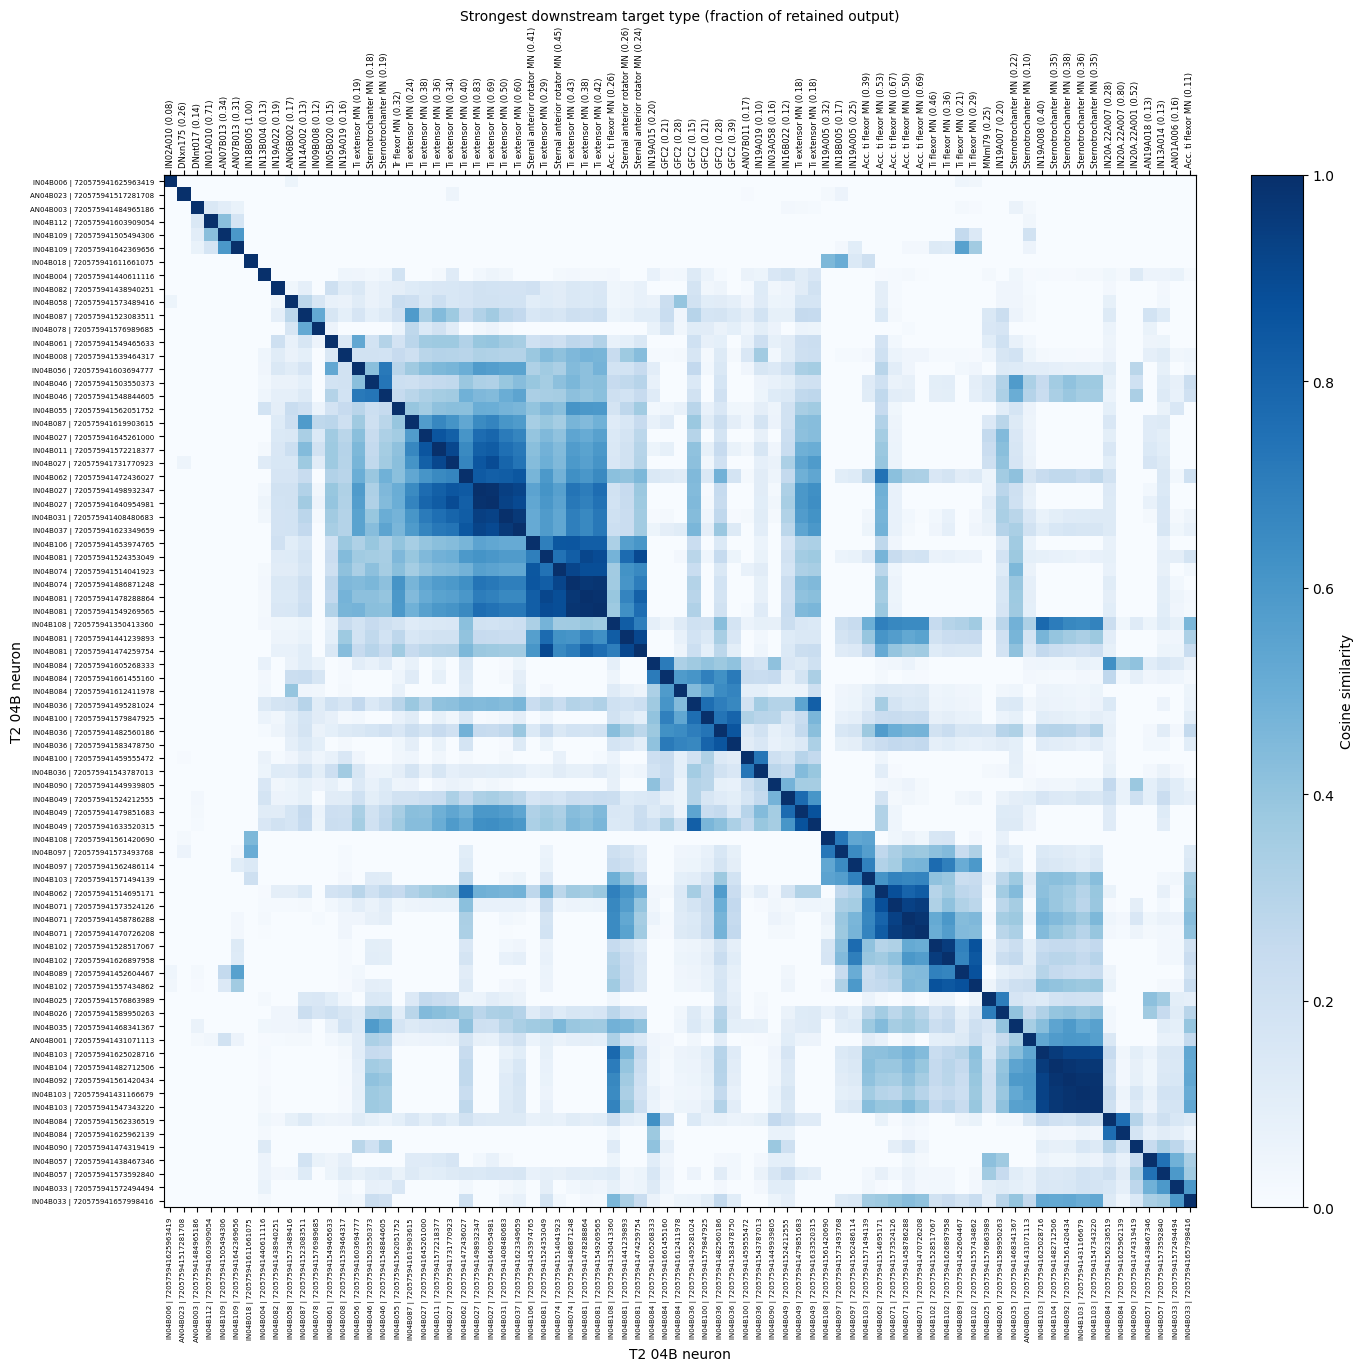

In [ ]:
#coside plot
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n==========================================")
print("04B COSINE SIMILARITY")
print("==========================================")

# ============================================================
# 1. CALCULATE NEURON × NEURON COSINE SIMILARITY
#
# normalized already contains:
# - >=10 synapse cutoff
# - rows = individual 04B neurons
# - columns = ALL retained downstream target types
# ============================================================

print("\nCalculating cosine similarity...")

cosine_sim = cosine_similarity(
    normalized.values
)

cosine_df = pd.DataFrame(
    cosine_sim,
    index=normalized.index,
    columns=normalized.index
)

print("✓ Cosine similarity matrix created")
print(f"  Matrix dimensions: {cosine_df.shape}")


# ============================================================
# 2. ORDER USING SAME ROW CLUSTERING AS CONNECTIVITY HEATMAP
#
# This is important:
# we are NOT reclustering here.
# We reuse row_order from the all-target connectivity analysis.
# ============================================================

cosine_clustered = cosine_df.iloc[
    row_order,
    row_order
]

print("✓ Using same neuron order as connectivity heatmap")


# ============================================================
# 3. NEURON LABELS
# ============================================================

labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type
    in cosine_clustered.index
]


# ============================================================
# 4. FIND STRONGEST DOWNSTREAM TARGET FOR EACH NEURON
#
# Uses the same >=10 filtered normalized matrix.
# ============================================================

top_target_per_neuron = normalized.idxmax(
    axis=1
)

top_fraction_per_neuron = normalized.max(
    axis=1
)

top_labels = pd.Series(
    [
        f"{target} ({fraction:.2f})"
        for target, fraction
        in zip(
            top_target_per_neuron,
            top_fraction_per_neuron
        )
    ],
    index=normalized.index
)

top_labels_clustered = top_labels.iloc[
    row_order
]

print("✓ Strongest downstream target identified")


# ============================================================
# 5. PLOT COSINE SIMILARITY
# ============================================================

print("\nCreating cosine similarity heatmap...")

fig, ax = plt.subplots(
    figsize=(16, 16)
)

im = ax.imshow(
    cosine_clustered.values,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="equal",
    interpolation="nearest"
)


# ============================================================
# 6. BOTTOM X AXIS = 04B NEURONS
# ============================================================

ax.set_xticks(
    range(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=90,
    fontsize=5
)


# ============================================================
# 7. Y AXIS = 04B NEURONS
# ============================================================

ax.set_yticks(
    range(len(labels))
)

ax.set_yticklabels(
    labels,
    fontsize=5
)

ax.set_xlabel(
    "T2 04B neuron"
)

ax.set_ylabel(
    "T2 04B neuron"
)


# ============================================================
# 8. TOP AXIS = STRONGEST DOWNSTREAM TARGET
#
# Example:
# Ti extensor MN (0.28)
# ============================================================

ax_top = ax.secondary_xaxis(
    "top"
)

ax_top.set_xticks(
    range(len(labels))
)

ax_top.set_xticklabels(
    top_labels_clustered.values,
    rotation=90,
    fontsize=6
)

ax_top.set_xlabel(
    "Strongest downstream target type "
    "(fraction of retained output)"
)

ax_top.tick_params(
    axis="x",
    pad=2
)


# ============================================================
# 9. COLOR BAR
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Cosine similarity"
)


# ============================================================
# 10. LAYOUT
#
# Leave room at top for target labels.
# ============================================================

plt.tight_layout()

plt.subplots_adjust(
    top=0.72
)


# ============================================================
# 11. SAVE
# ============================================================

pdf_name = (
    f"04B_cosine_similarity_"
    f"min{MIN_SYNAPSES}syn.pdf"
)

png_name = (
    f"04B_cosine_similarity_"
    f"min{MIN_SYNAPSES}syn.png"
)

plt.savefig(
    pdf_name,
    bbox_inches="tight"
)

plt.savefig(
    png_name,
    dpi=300,
    bbox_inches="tight"
)

print("\n✓ Cosine similarity heatmap complete")
print("✓ Saved:")
print(f"  {pdf_name}")
print(f"  {png_name}")


# ============================================================
# 12. DISPLAY
# ============================================================

plt.show()

#add row annotation trip for birth time 



In [ ]:
# ============================================================
# ADD BIRTHTIME ANNOTATION TO BANC SOURCE NEURONS
# ============================================================

birthtime_lookup = (
    manc_t2_04b[
        ["bodyid", "birthtime"]
    ]
    .drop_duplicates(subset="bodyid")
    .rename(
        columns={
            "bodyid": "manc_bodyid"
        }
    )
)

bundle_T2_04B = bundle_T2_04B.merge(
    birthtime_lookup,
    on="manc_bodyid",
    how="left"
)

print("Birthtime annotations:")
print(
    bundle_T2_04B["birthtime"]
    .value_counts(dropna=False)
)

Birthtime annotations:
birthtime
secondary          58
early secondary    15
primary             4
Name: count, dtype: int64


In [ ]:
# ============================================================
# MATCH BIRTHTIME TO HEATMAP ROW ORDER
# ============================================================

source_birthtime = (
    bundle_T2_04B[
        ["pt_root_id", "birthtime"]
    ]
    .drop_duplicates(subset="pt_root_id")
    .set_index("pt_root_id")["birthtime"]
)

birthtime_ordered = [
    source_birthtime.get(source_id, "unknown")
    for source_id, source_type
    in plot_matrix.index
]

print("Birthtimes in plotted row order:")
print(pd.Series(birthtime_ordered).value_counts())

Birthtimes in plotted row order:
secondary          58
early secondary    15
primary             4
Name: count, dtype: int64



Birthtime categories:
['early secondary', 'primary', 'secondary']
✓ Birthtime annotation added
✓ Birthtime blocks remain locked to neuron rows
✓ Saved:
  04B_connectivity_with_birthtime.pdf
  04B_connectivity_with_birthtime.png


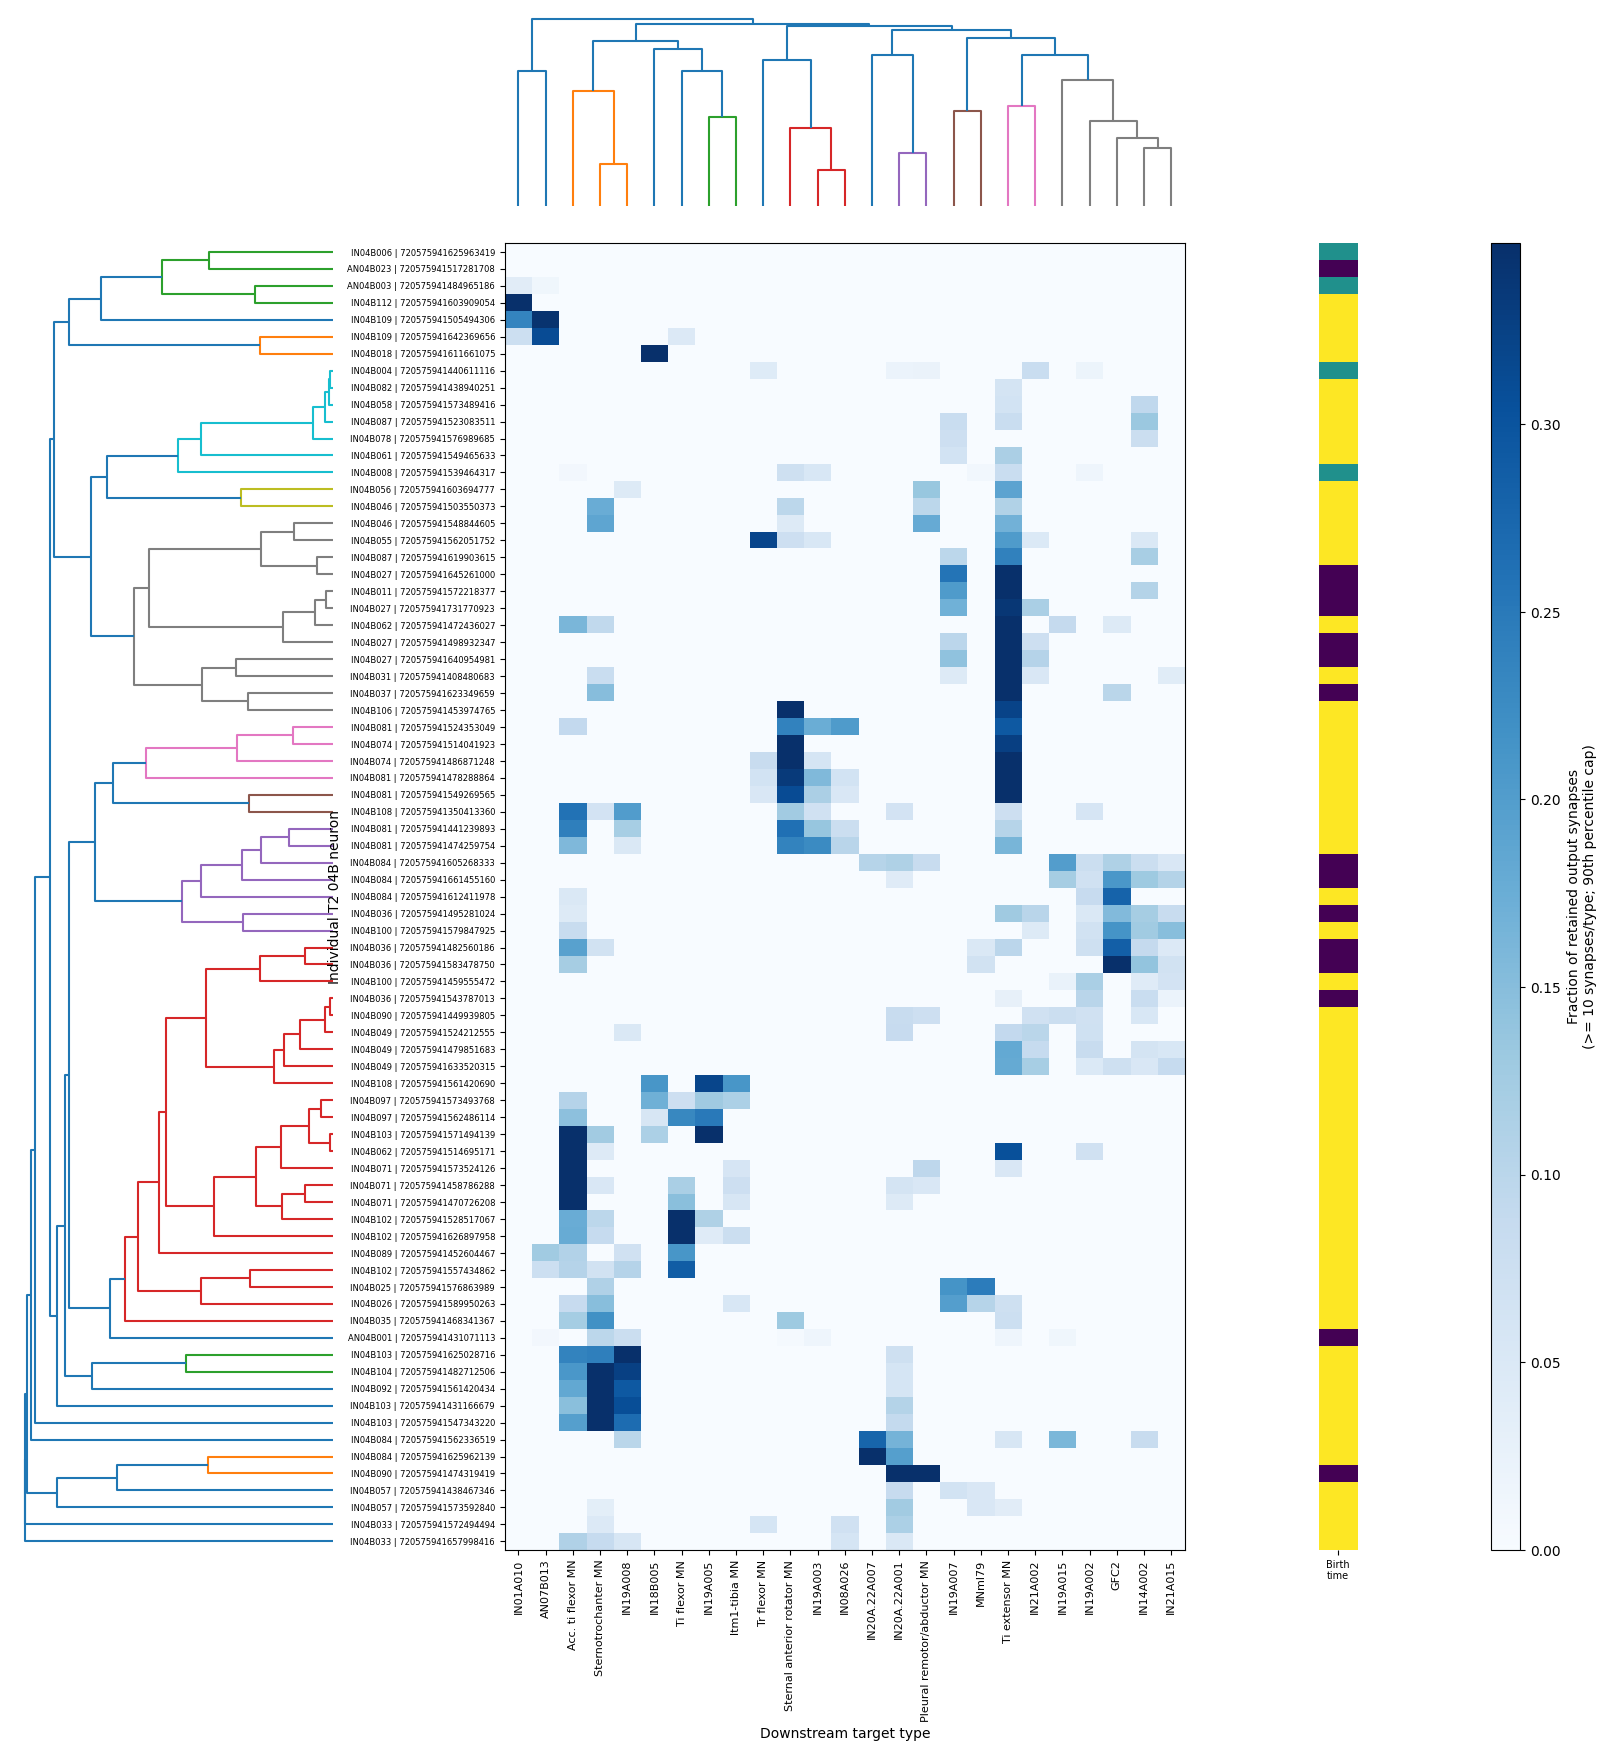

In [ ]:
# ============================================================
# BIRTHTIME ANNOTATION STRIP
# ============================================================

from matplotlib.colors import ListedColormap

# Replace missing birthtime values
birthtime_ordered = [
    x if pd.notna(x) else "unknown"
    for x in birthtime_ordered
]

# Find unique birthtime categories
birth_categories = sorted(
    pd.Series(birthtime_ordered).unique()
)

print("\nBirthtime categories:")
print(birth_categories)

# Convert categories to numbers for plotting
birth_to_number = {
    category: i
    for i, category in enumerate(birth_categories)
}

birth_values = np.array(
    [
        birth_to_number[x]
        for x in birthtime_ordered
    ]
).reshape(-1, 1)

# ============================================================
# FIGURE LAYOUT
#
# dendrogram | heatmap | birthtime | colorbar
#
# The neuron labels remain on the LEFT side of the heatmap,
# so the birthtime strip cannot overlap them.
# ============================================================

fig = plt.figure(figsize=(19, 20))

gs = fig.add_gridspec(
    2,
    4,
    width_ratios=[
        3.8,   # row dendrogram
        8,     # heatmap
        0.45,  # birthtime strip
        0.35   # colorbar
    ],
    height_ratios=[
        1.2,   # column dendrogram
        8
    ],
    wspace=0.50,
    hspace=0.05
)


# ============================================================
# COLUMN DENDROGRAM
# ============================================================

ax_col_dendro = fig.add_subplot(gs[0, 1])

dendrogram(
    Z_columns,
    orientation="top",
    no_labels=True,
    ax=ax_col_dendro
)

ax_col_dendro.set_xticks([])
ax_col_dendro.set_yticks([])

for spine in ax_col_dendro.spines.values():
    spine.set_visible(False)


# ============================================================
# ROW DENDROGRAM
# ============================================================

ax_row_dendro = fig.add_subplot(gs[1, 0])

dendrogram(
    Z_rows,
    orientation="left",
    no_labels=True,
    ax=ax_row_dendro
)

ax_row_dendro.set_xticks([])
ax_row_dendro.set_yticks([])

for spine in ax_row_dendro.spines.values():
    spine.set_visible(False)
# ============================================================
# SHIFT ROW DENDROGRAM FARTHER LEFT
# ============================================================

pos = ax_row_dendro.get_position()

ax_row_dendro.set_position([
    pos.x0 - 0.02,   # move left
    pos.y0,
    pos.width,
    pos.height
])

# ------------------------------------------------------------
# Move BIRTHTIME strip LEFT toward heatmap
# ------------------------------------------------------------

pos = ax_birth.get_position()

ax_birth.set_position([
    pos.x0 - 0.20,
    pos.y0,
    pos.width,
    pos.height
])


# ------------------------------------------------------------
# Move COLORBAR / SCALE LEFT
# ------------------------------------------------------------

pos = ax_cbar.get_position()

ax_cbar.set_position([
    pos.x0 - 0.20,
    pos.y0,
    pos.width,
    pos.height
])
# ============================================================
# CONNECTIVITY HEATMAP
# ============================================================

ax_heatmap = fig.add_subplot(gs[1, 1])

im = ax_heatmap.imshow(
    plot_matrix.values,
    cmap="Blues",
    vmin=0,
    vmax=vmax_cap,
    aspect="auto",
    interpolation="nearest"
)

ax_heatmap.set_xticks(
    range(len(plot_matrix.columns))
)

ax_heatmap.set_xticklabels(
    plot_matrix.columns,
    rotation=90,
    fontsize=8
)

ax_heatmap.set_yticks(
    range(len(plot_matrix.index))
)

ax_heatmap.set_yticklabels(
    row_labels,
    fontsize=6
)

ax_heatmap.set_xlabel(
    "Downstream target type"
)

ax_heatmap.set_ylabel(
    "Individual T2 04B neuron"
)


# ============================================================
# BIRTHTIME STRIP
#
# This is now to the RIGHT of the heatmap.
# It uses birthtime_ordered, which was generated directly
# from plot_matrix.index, so every block remains matched
# to the correct neuron.
# ============================================================

ax_birth = fig.add_subplot(gs[1, 2])

ax_birth.imshow(
    birth_values,
    aspect="auto",
    interpolation="nearest"
)

ax_birth.set_xticks([0])

ax_birth.set_xticklabels(
    ["Birth\ntime"],
    fontsize=7
)

ax_birth.set_yticks([])

for spine in ax_birth.spines.values():
    spine.set_visible(False)


# ============================================================
# COLORBAR
# ============================================================

ax_cbar = fig.add_subplot(gs[1, 3])

cbar = fig.colorbar(
    im,
    cax=ax_cbar
)

cbar.set_label(
    f"Fraction of retained output synapses\n"
    f"(>= {MIN_SYNAPSES} synapses/type; "
    f"{PERCENTILE_CAP}th percentile cap)"
)


# ============================================================
# SAVE
# ============================================================

pdf_name = "04B_connectivity_with_birthtime.pdf"
png_name = "04B_connectivity_with_birthtime.png"

plt.savefig(
    pdf_name,
    bbox_inches="tight"
)

plt.savefig(
    png_name,
    dpi=300,
    bbox_inches="tight"
)

print("✓ Birthtime annotation added")
print("✓ Birthtime blocks remain locked to neuron rows")
print("✓ Saved:")
print(f"  {pdf_name}")
print(f"  {png_name}")

plt.show()



04B COSINE SIMILARITY + BIRTHTIME

Determining neuron order...
✓ Row order determined
✓ Cosine similarity matrix created

Birthtime categories:
['early secondary', 'primary', 'secondary']

First 10 plotted neurons:
 0: IN04B006 | 720575941625963419 | birthtime=primary
 1: AN04B023 | 720575941517281708 | birthtime=early secondary
 2: AN04B003 | 720575941484965186 | birthtime=primary
 3: IN04B112 | 720575941603909054 | birthtime=secondary
 4: IN04B109 | 720575941505494306 | birthtime=secondary
 5: IN04B109 | 720575941642369656 | birthtime=secondary
 6: IN04B018 | 720575941611661075 | birthtime=secondary
 7: IN04B004 | 720575941440611116 | birthtime=primary
 8: IN04B082 | 720575941438940251 | birthtime=secondary
 9: IN04B058 | 720575941573489416 | birthtime=secondary

✓ Cosine plot complete
✓ Birthtime strip matched exactly to heatmap height
✓ Birthtime order derived directly from plotted rows
✓ Saved:
  04B_cosine_similarity_with_birthtime_aligned.pdf
  04B_cosine_similarity_with_birtht

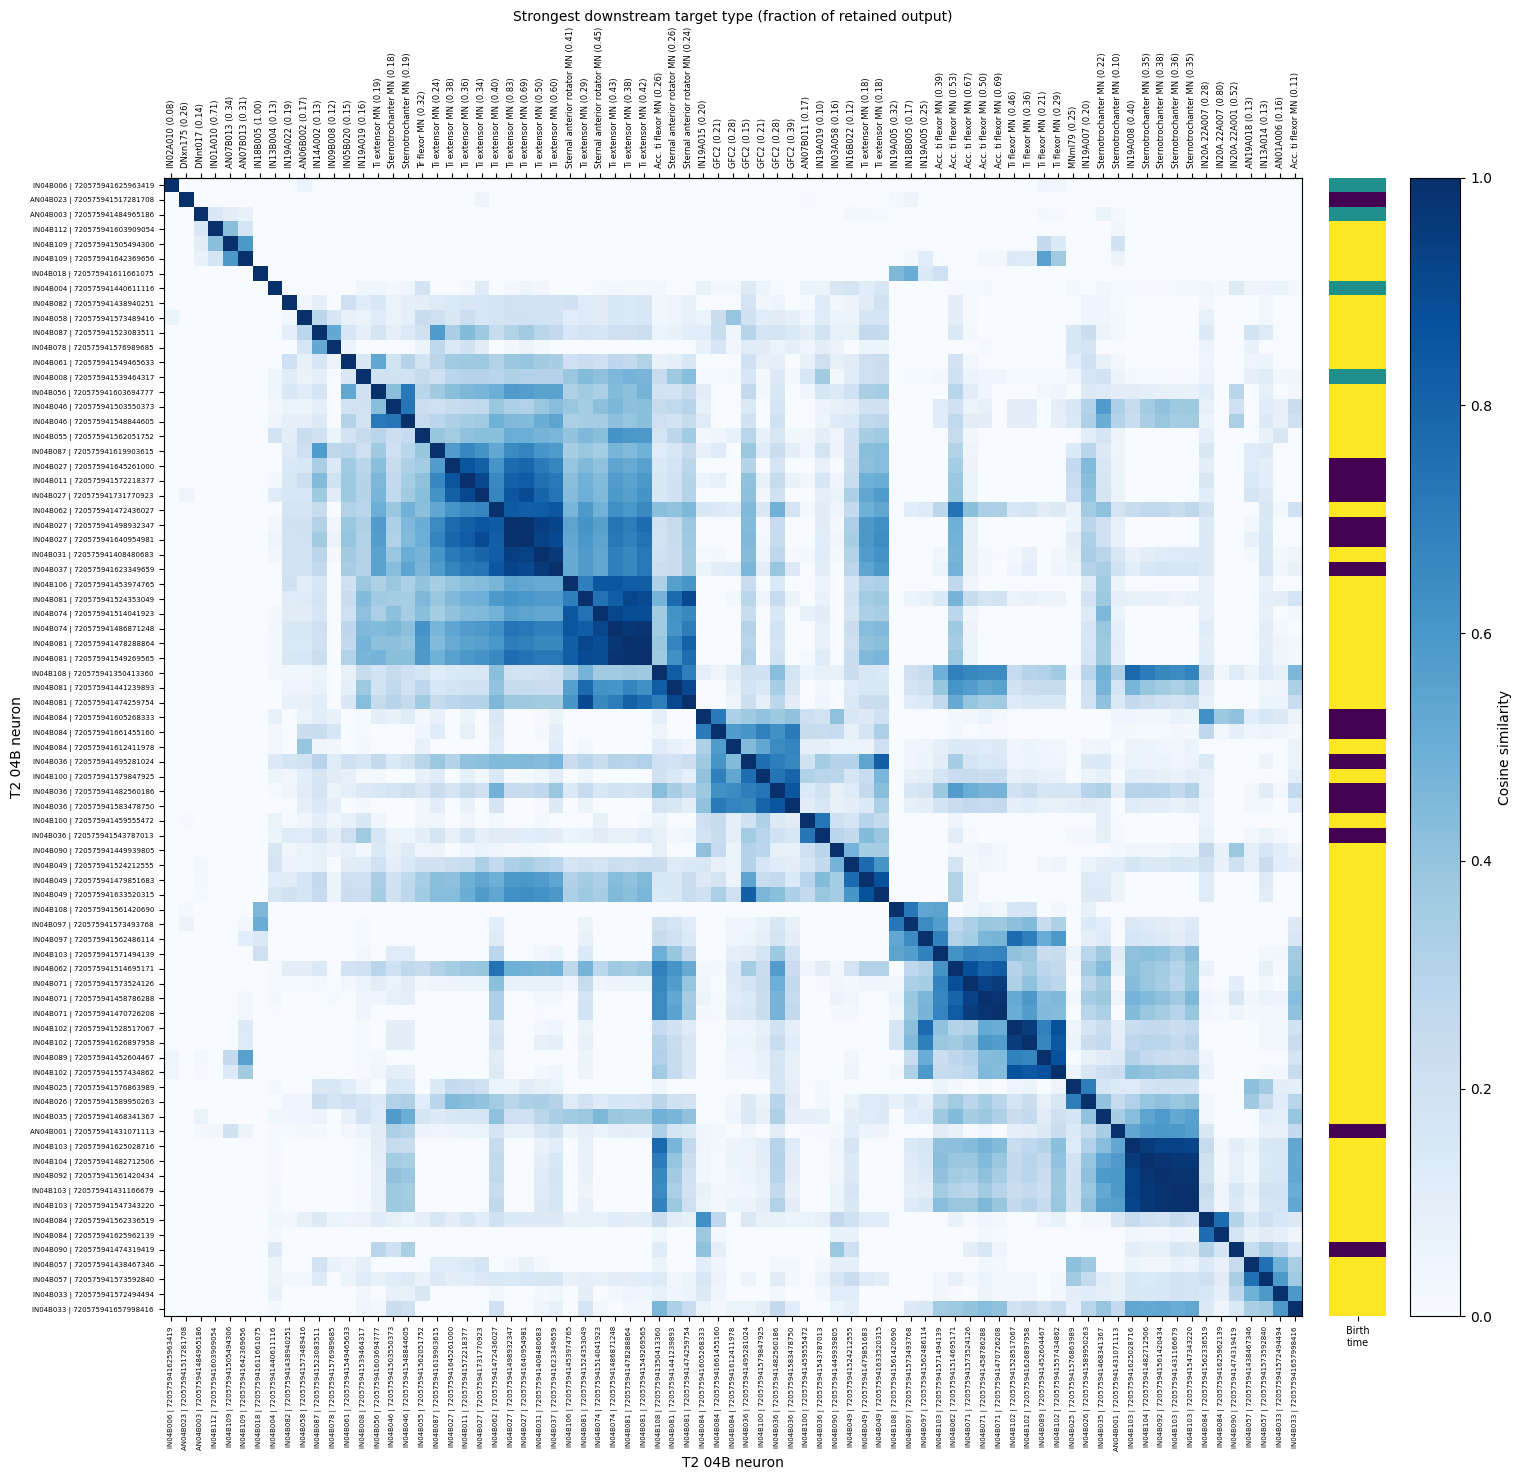

In [ ]:
#cosine plot with birth time. recalculate from source matric to makse sure  its corretly matched to the cell in the row in the position it has in this plot 
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

print("\n==========================================")
print("04B COSINE SIMILARITY + BIRTHTIME")
print("==========================================")

# ============================================================
# 1. DETERMINE ROW ORDER FROM FULL CONNECTIVITY PROFILE
# ============================================================

print("\nDetermining neuron order...")

row_distance_cosine = pdist(
    normalized.values,
    metric="cosine"
)

Z_rows_cosine = linkage(
    row_distance_cosine,
    method="average"
)

row_order_cosine = leaves_list(
    Z_rows_cosine
)

print("✓ Row order determined")


# ============================================================
# 2. CALCULATE COSINE SIMILARITY
# ============================================================

cosine_sim = cosine_similarity(
    normalized.values
)

cosine_df = pd.DataFrame(
    cosine_sim,
    index=normalized.index,
    columns=normalized.index
)

cosine_clustered = cosine_df.iloc[
    row_order_cosine,
    row_order_cosine
]

print("✓ Cosine similarity matrix created")


# ============================================================
# 3. CELL LABELS
# ============================================================

labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type
    in cosine_clustered.index
]


# ============================================================
# 4. TOP DOWNSTREAM TARGET FOR EACH NEURON
# ============================================================

top_target_per_neuron = normalized.idxmax(
    axis=1
)

top_fraction_per_neuron = normalized.max(
    axis=1
)

top_labels = pd.Series(
    [
        f"{target} ({fraction:.2f})"
        for target, fraction
        in zip(
            top_target_per_neuron,
            top_fraction_per_neuron
        )
    ],
    index=normalized.index
)

top_labels_clustered = top_labels.loc[
    cosine_clustered.index
]


# ============================================================
# 5. BIRTHTIME IN EXACT PLOTTED ROW ORDER
# ============================================================

birthtime_ordered_cosine = [
    source_birthtime.get(
        source_id,
        "unknown"
    )
    for source_id, source_type
    in cosine_clustered.index
]

birthtime_ordered_cosine = [
    x if pd.notna(x) else "unknown"
    for x in birthtime_ordered_cosine
]

birth_categories = sorted(
    pd.Series(
        birthtime_ordered_cosine
    ).unique()
)

birth_to_number = {
    category: i
    for i, category
    in enumerate(birth_categories)
}

birth_values_cosine = np.array(
    [
        birth_to_number[x]
        for x in birthtime_ordered_cosine
    ]
).reshape(-1, 1)

print("\nBirthtime categories:")
print(birth_categories)


# ============================================================
# 6. VERIFY ALIGNMENT
# ============================================================

print("\nFirst 10 plotted neurons:")

for i, ((source_id, source_type), birthtime) in enumerate(
    zip(
        cosine_clustered.index[:10],
        birthtime_ordered_cosine[:10]
    )
):
    print(
        f"{i:2d}: "
        f"{source_type} | {source_id} | "
        f"birthtime={birthtime}"
    )


# ============================================================
# 7. FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(18, 16)
)

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[
        8,      # cosine matrix
        0.40,   # birthtime
        0.35    # colorbar
    ],
    wspace=0.18
)


# ============================================================
# 8. COSINE HEATMAP
# ============================================================

ax = fig.add_subplot(
    gs[0, 0]
)

im = ax.imshow(
    cosine_clustered.values,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="equal",
    interpolation="nearest"
)

ax.set_xticks(
    range(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=90,
    fontsize=5
)

ax.set_yticks(
    range(len(labels))
)

ax.set_yticklabels(
    labels,
    fontsize=5
)

ax.set_xlabel(
    "T2 04B neuron"
)

ax.set_ylabel(
    "T2 04B neuron"
)


# ============================================================
# 9. TOP AXIS = STRONGEST DOWNSTREAM TARGET
# ============================================================

ax_top = ax.secondary_xaxis(
    "top"
)

ax_top.set_xticks(
    range(len(labels))
)

ax_top.set_xticklabels(
    top_labels_clustered.values,
    rotation=90,
    fontsize=6
)

ax_top.set_xlabel(
    "Strongest downstream target type "
    "(fraction of retained output)"
)


# ============================================================
# 10. BIRTHTIME STRIP
# ============================================================

ax_birth = fig.add_subplot(
    gs[0, 1]
)

ax_birth.imshow(
    birth_values_cosine,
    aspect="auto",
    interpolation="nearest"
)

ax_birth.set_xticks([0])

ax_birth.set_xticklabels(
    ["Birth\ntime"],
    fontsize=7
)

ax_birth.set_yticks([])

for spine in ax_birth.spines.values():
    spine.set_visible(False)


# ============================================================
# 11. COLORBAR
# ============================================================

ax_cbar = fig.add_subplot(
    gs[0, 2]
)

cbar = fig.colorbar(
    im,
    cax=ax_cbar
)

cbar.set_label(
    "Cosine similarity"
)


# ============================================================
# 12. FORCE BIRTHTIME + COLORBAR TO MATCH SQUARE HEATMAP
# ============================================================

# Calculate final square heatmap position
fig.canvas.draw()

heat_pos = ax.get_position()

birth_pos = ax_birth.get_position()

# Birthtime strip:
# exact same vertical position + height as cosine matrix
ax_birth.set_position([
    heat_pos.x1 + 0.015,
    heat_pos.y0,
    birth_pos.width,
    heat_pos.height
])

cbar_pos = ax_cbar.get_position()

# Colorbar:
# exact same vertical position + height
ax_cbar.set_position([
    heat_pos.x1 + 0.060,
    heat_pos.y0,
    cbar_pos.width,
    heat_pos.height
])


# ============================================================
# 13. SAVE
# ============================================================

pdf_name = (
    "04B_cosine_similarity_with_birthtime_aligned.pdf"
)

png_name = (
    "04B_cosine_similarity_with_birthtime_aligned.png"
)

plt.savefig(
    pdf_name,
    bbox_inches="tight"
)

plt.savefig(
    png_name,
    dpi=300,
    bbox_inches="tight"
)

print("\n✓ Cosine plot complete")
print("✓ Birthtime strip matched exactly to heatmap height")
print("✓ Birthtime order derived directly from plotted rows")
print("✓ Saved:")
print(f"  {pdf_name}")
print(f"  {png_name}")

plt.show()

In [ ]:
#now we make the plots but only consider as targets neurosn that are motor neurons

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist
from sklearn.metrics.pairwise import cosine_similarity

print("\n==========================================")
print("04B MOTOR-NEURON TARGET ANALYSIS")
print("==========================================")

# ============================================================
# SETTINGS
# ============================================================

MIN_SYNAPSES = 10
PERCENTILE_CAP = 95


# ============================================================
# 1. KEEP ONLY MOTOR-NEURON TARGETS
# ============================================================

mn_df = results[
    results["target_type"]
    .astype(str)
    .str.contains(r"\bMN\b", regex=True, na=False)
].copy()

print(f"\nConnections to MN targets: {len(mn_df):,}")
print(f"Source neurons represented: {mn_df['source_id'].nunique()}")
print(f"MN target types: {mn_df['target_type'].nunique()}")

print("\nMotor-neuron target types found:")
print(
    sorted(
        mn_df["target_type"]
        .dropna()
        .unique()
    )
)


# ============================================================
# 2. COLLAPSE INDIVIDUAL TARGET NEURONS INTO MN TARGET TYPES
# ============================================================

mn_grouped = (
    mn_df.groupby(
        [
            "source_id",
            "source_type",
            "target_type"
        ],
        as_index=False
    )["synapses"]
    .sum()
)


# ============================================================
# 3. APPLY >=10 SYNAPSE CUTOFF
# ============================================================

mn_grouped = mn_grouped[
    mn_grouped["synapses"] >= MIN_SYNAPSES
].copy()

print(
    f"\nAfter >= {MIN_SYNAPSES} synapse cutoff:"
)

print(
    f"  Source neurons: "
    f"{mn_grouped['source_id'].nunique()}"
)

print(
    f"  MN target types: "
    f"{mn_grouped['target_type'].nunique()}"
)


# ============================================================
# 4. BUILD SOURCE-NEURON x MN-TARGET MATRIX
# ============================================================

mn_matrix = mn_grouped.pivot_table(
    index=[
        "source_id",
        "source_type"
    ],
    columns="target_type",
    values="synapses",
    aggfunc="sum",
    fill_value=0
)

print(
    f"\nMN connectivity matrix: "
    f"{mn_matrix.shape[0]} neurons x "
    f"{mn_matrix.shape[1]} MN types"
)


# ============================================================
# 5. NORMALIZE WITHIN MN OUTPUT
#
# IMPORTANT:
# These fractions now mean:
# fraction of RETAINED MOTOR-NEURON output,
# not fraction of all neuronal output.
# ============================================================

mn_normalized = mn_matrix.div(
    mn_matrix.sum(axis=1),
    axis=0
).fillna(0)

# Remove empty rows/columns
mn_normalized = mn_normalized.loc[
    np.linalg.norm(mn_normalized.values, axis=1) > 0
]

mn_normalized = mn_normalized.loc[
    :,
    np.linalg.norm(mn_normalized.values, axis=0) > 0
]


# ============================================================
# 6. CLUSTER 04B NEURONS BY THEIR MN TARGET PROFILE
# ============================================================

mn_row_distance = pdist(
    mn_normalized.values,
    metric="cosine"
)

mn_Z_rows = linkage(
    mn_row_distance,
    method="average"
)

mn_row_order = leaves_list(
    mn_Z_rows
)


# ============================================================
# 7. CLUSTER MN TARGET COLUMNS
# ============================================================

mn_col_distance = pdist(
    mn_normalized.T.values,
    metric="cosine"
)

mn_Z_columns = linkage(
    mn_col_distance,
    method="average"
)

mn_col_order = leaves_list(
    mn_Z_columns
)


# ============================================================
# 8. REORDER MATRIX
# ============================================================

mn_plot_matrix = mn_normalized.iloc[
    mn_row_order,
    mn_col_order
]


# ============================================================
# 9. CONTRAST CAP
# ============================================================

mn_nonzero = mn_plot_matrix.values[
    mn_plot_matrix.values > 0
]

mn_vmax = np.percentile(
    mn_nonzero,
    PERCENTILE_CAP
)


# ============================================================
# 10. ROW LABELS
# ============================================================

mn_row_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type
    in mn_plot_matrix.index
]


# ============================================================
# 11. MOTOR-NEURON CONNECTIVITY HEATMAP
# ============================================================

fig = plt.figure(figsize=(17, 18))

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[3.8, 8, 0.35],
    height_ratios=[1.2, 8],
    wspace=0.50,
    hspace=0.05
)

# Column dendrogram
ax_col = fig.add_subplot(gs[0, 1])

dendrogram(
    mn_Z_columns,
    orientation="top",
    no_labels=True,
    ax=ax_col
)

ax_col.set_xticks([])
ax_col.set_yticks([])

for spine in ax_col.spines.values():
    spine.set_visible(False)

# Row dendrogram
ax_row = fig.add_subplot(gs[1, 0])

dendrogram(
    mn_Z_rows,
    orientation="left",
    no_labels=True,
    ax=ax_row
)

ax_row.set_xticks([])
ax_row.set_yticks([])

for spine in ax_row.spines.values():
    spine.set_visible(False)

# Shift dendrogram left
pos = ax_row.get_position()

ax_row.set_position([
    pos.x0 - 0.05,
    pos.y0,
    pos.width,
    pos.height
])

# Heatmap
ax_heat = fig.add_subplot(gs[1, 1])

im = ax_heat.imshow(
    mn_plot_matrix.values,
    cmap="Blues",
    vmin=0,
    vmax=mn_vmax,
    aspect="auto",
    interpolation="nearest"
)

ax_heat.set_xticks(
    range(len(mn_plot_matrix.columns))
)

ax_heat.set_xticklabels(
    mn_plot_matrix.columns,
    rotation=90,
    fontsize=8
)

ax_heat.set_yticks(
    range(len(mn_plot_matrix.index))
)

ax_heat.set_yticklabels(
    mn_row_labels,
    fontsize=6
)

ax_heat.set_xlabel(
    "Motor-neuron target type"
)

ax_heat.set_ylabel(
    "Individual T2 04B neuron"
)

# Colorbar
ax_cbar = fig.add_subplot(gs[1, 2])

cbar = fig.colorbar(
    im,
    cax=ax_cbar
)

cbar.set_label(
    f"Fraction of retained MN-directed output\n"
    f"(>= {MIN_SYNAPSES} synapses/type; "
    f"{PERCENTILE_CAP}th percentile cap)"
)

plt.savefig(
    "04B_MN_targets_connectivity_heatmap.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "04B_MN_targets_connectivity_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. COSINE SIMILARITY — MN TARGETS ONLY
# ============================================================

mn_cosine = cosine_similarity(
    mn_normalized.values
)

mn_cosine_df = pd.DataFrame(
    mn_cosine,
    index=mn_normalized.index,
    columns=mn_normalized.index
)

mn_cosine_clustered = mn_cosine_df.iloc[
    mn_row_order,
    mn_row_order
]

mn_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type
    in mn_cosine_clustered.index
]

fig, ax = plt.subplots(
    figsize=(15, 15)
)

im = ax.imshow(
    mn_cosine_clustered.values,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="equal",
    interpolation="nearest"
)

ax.set_xticks(
    range(len(mn_labels))
)

ax.set_xticklabels(
    mn_labels,
    rotation=90,
    fontsize=5
)

ax.set_yticks(
    range(len(mn_labels))
)

ax.set_yticklabels(
    mn_labels,
    fontsize=5
)

ax.set_xlabel(
    "T2 04B neuron"
)

ax.set_ylabel(
    "T2 04B neuron"
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Cosine similarity of MN-target profiles"
)

plt.tight_layout()

plt.savefig(
    "04B_MN_targets_cosine_similarity.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "04B_MN_targets_cosine_similarity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ MN-only analysis complete")

In [3]:
# ============================================================
# RELOAD SAVED BANC 04B CONNECTIVITY DATA
# ============================================================

import pandas as pd
import numpy as np

RESULTS_FILE = (
    r"C:\Users\JHS\Documents\Python\project_folder_4B"
    r"\Faculty_Statement\BANC_04B_T2_connectivity.csv"
)

print("Loading 04B connectivity data...")

results = pd.read_csv(
    RESULTS_FILE
)

print("✓ Connectivity data loaded")
print(f"  Rows: {len(results):,}")
print(f"  Source neurons: {results['source_id'].nunique()}")
print(f"  Source types: {results['source_type'].nunique()}")
print(f"  Target neurons: {results['target_id'].nunique()}")
print(f"  Target types: {results['target_type'].nunique()}")

print("\nColumns:")
print(results.columns.tolist())

display(results.head())

Loading 04B connectivity data...
✓ Connectivity data loaded
  Rows: 139,910
  Source neurons: 77
  Source types: 43
  Target neurons: 122722
  Target types: 1705

Columns:
['source_id', 'source_type', 'target_id', 'target_type', 'synapses']


,source_id,source_type,target_id,target_type,synapses
0,720575941350413360,IN04B108,720575940393185630,NaN,1
1,720575941350413360,IN04B108,720575940393285470,NaN,1
2,720575941350413360,IN04B108,720575940393395038,NaN,1
3,720575941350413360,IN04B108,720575940393537118,NaN,1
4,720575941350413360,IN04B108,720575940393537886,NaN,1


In [4]:
#self-condained  code to make cosine plot only considerign the MN targets and with birth time, top target and cell type additions



Building MN-only connectivity matrix...
MN connections found: 1,110
04B source neurons represented: 75
MN target types represented: 30
After >= 10 synapse cutoff: 163 / 581 source -> MN-type connections retained

✓ MN normalized matrix created:
  67 04B neurons
  16 MN target types
  Row sums: 1.000 - 1.000



04B MN COSINE SIMILARITY

STEP 1: Loading BANC connectivity...
✓ Loaded connectivity
  Rows: 139,910
  Source neurons: 77
  Source types: 43
  Target types: 1705

STEP 2: Loading MANC metadata...
✓ Loaded MANC metadata
  Rows: 187

STEP 3: Filtering to MN targets...
✓ MN-directed connections: 1,110
  Source neurons: 75
  MN target types: 30

>= 10 synapse cutoff: 163 / 581 retained
Source neurons retained: 67

MN matrix: 67 neurons × 16 MN target types

STEP 4: Clustering MN connectivity profiles...
✓ Row order determined
✓ Cosine matrix: (67, 67)
✓ Top MN target labels aligned
✓ 04B type annotation: 38 types

STEP 5: Rebuilding BANC → MANC lookup...
✓ Matched T2 04B BANC neurons: 78

MAPPING BIRTHTIME TO PLOTTED NEURONS

Plotted source neurons: 67
BANC neurons with MANC match: 67 / 67

Birthtimes among EXACT plotted neurons:
birthtime
secondary          51
early secondary    13
primary             3
Name: count, dtype: int64

Birthtime annotated: 67 / 67


,source_id,source_type,manc_match_id,manc_bodyid,birthtime
0,720575941625963419,IN04B006,id:12284,12284,primary
1,720575941605268333,IN04B084,id:21464,21464,early secondary
2,720575941449939805,IN04B090,id:20152,20152,secondary
3,720575941474319419,IN04B090,id:19484,19484,early secondary
4,720575941571494139,IN04B103,id:22342,22342,secondary
5,720575941458786288,IN04B071,id:35471,35471,secondary
6,720575941470726208,IN04B071,id:19844,19844,secondary
7,720575941573524126,IN04B071,id:21147,21147,secondary
8,720575941579847925,IN04B100,id:22988,22988,secondary
9,720575941583478750,IN04B036,id:16772,16772,early secondary



Birthtime strip order:
secondary          51
early secondary    13
primary             3
Name: count, dtype: int64

Birthtime categories used:
['primary', 'early secondary', 'secondary']

First 10 plotted neurons:
 0: IN04B006 | 720575941625963419 | birthtime=primary | topMN=hg1 MN (0.40)
 1: IN04B084 | 720575941605268333 | birthtime=early secondary | topMN=Pleural remotor/abductor MN (1.00)
 2: IN04B090 | 720575941449939805 | birthtime=secondary | topMN=Pleural remotor/abductor MN (1.00)
 3: IN04B090 | 720575941474319419 | birthtime=early secondary | topMN=Pleural remotor/abductor MN (1.00)
 4: IN04B103 | 720575941571494139 | birthtime=secondary | topMN=Acc. ti flexor MN (0.76)
 5: IN04B071 | 720575941458786288 | birthtime=secondary | topMN=Acc. ti flexor MN (0.63)
 6: IN04B071 | 720575941470726208 | birthtime=secondary | topMN=Acc. ti flexor MN (0.77)
 7: IN04B071 | 720575941573524126 | birthtime=secondary | topMN=Acc. ti flexor MN (0.77)
 8: IN04B100 | 720575941579847925 | birthtim

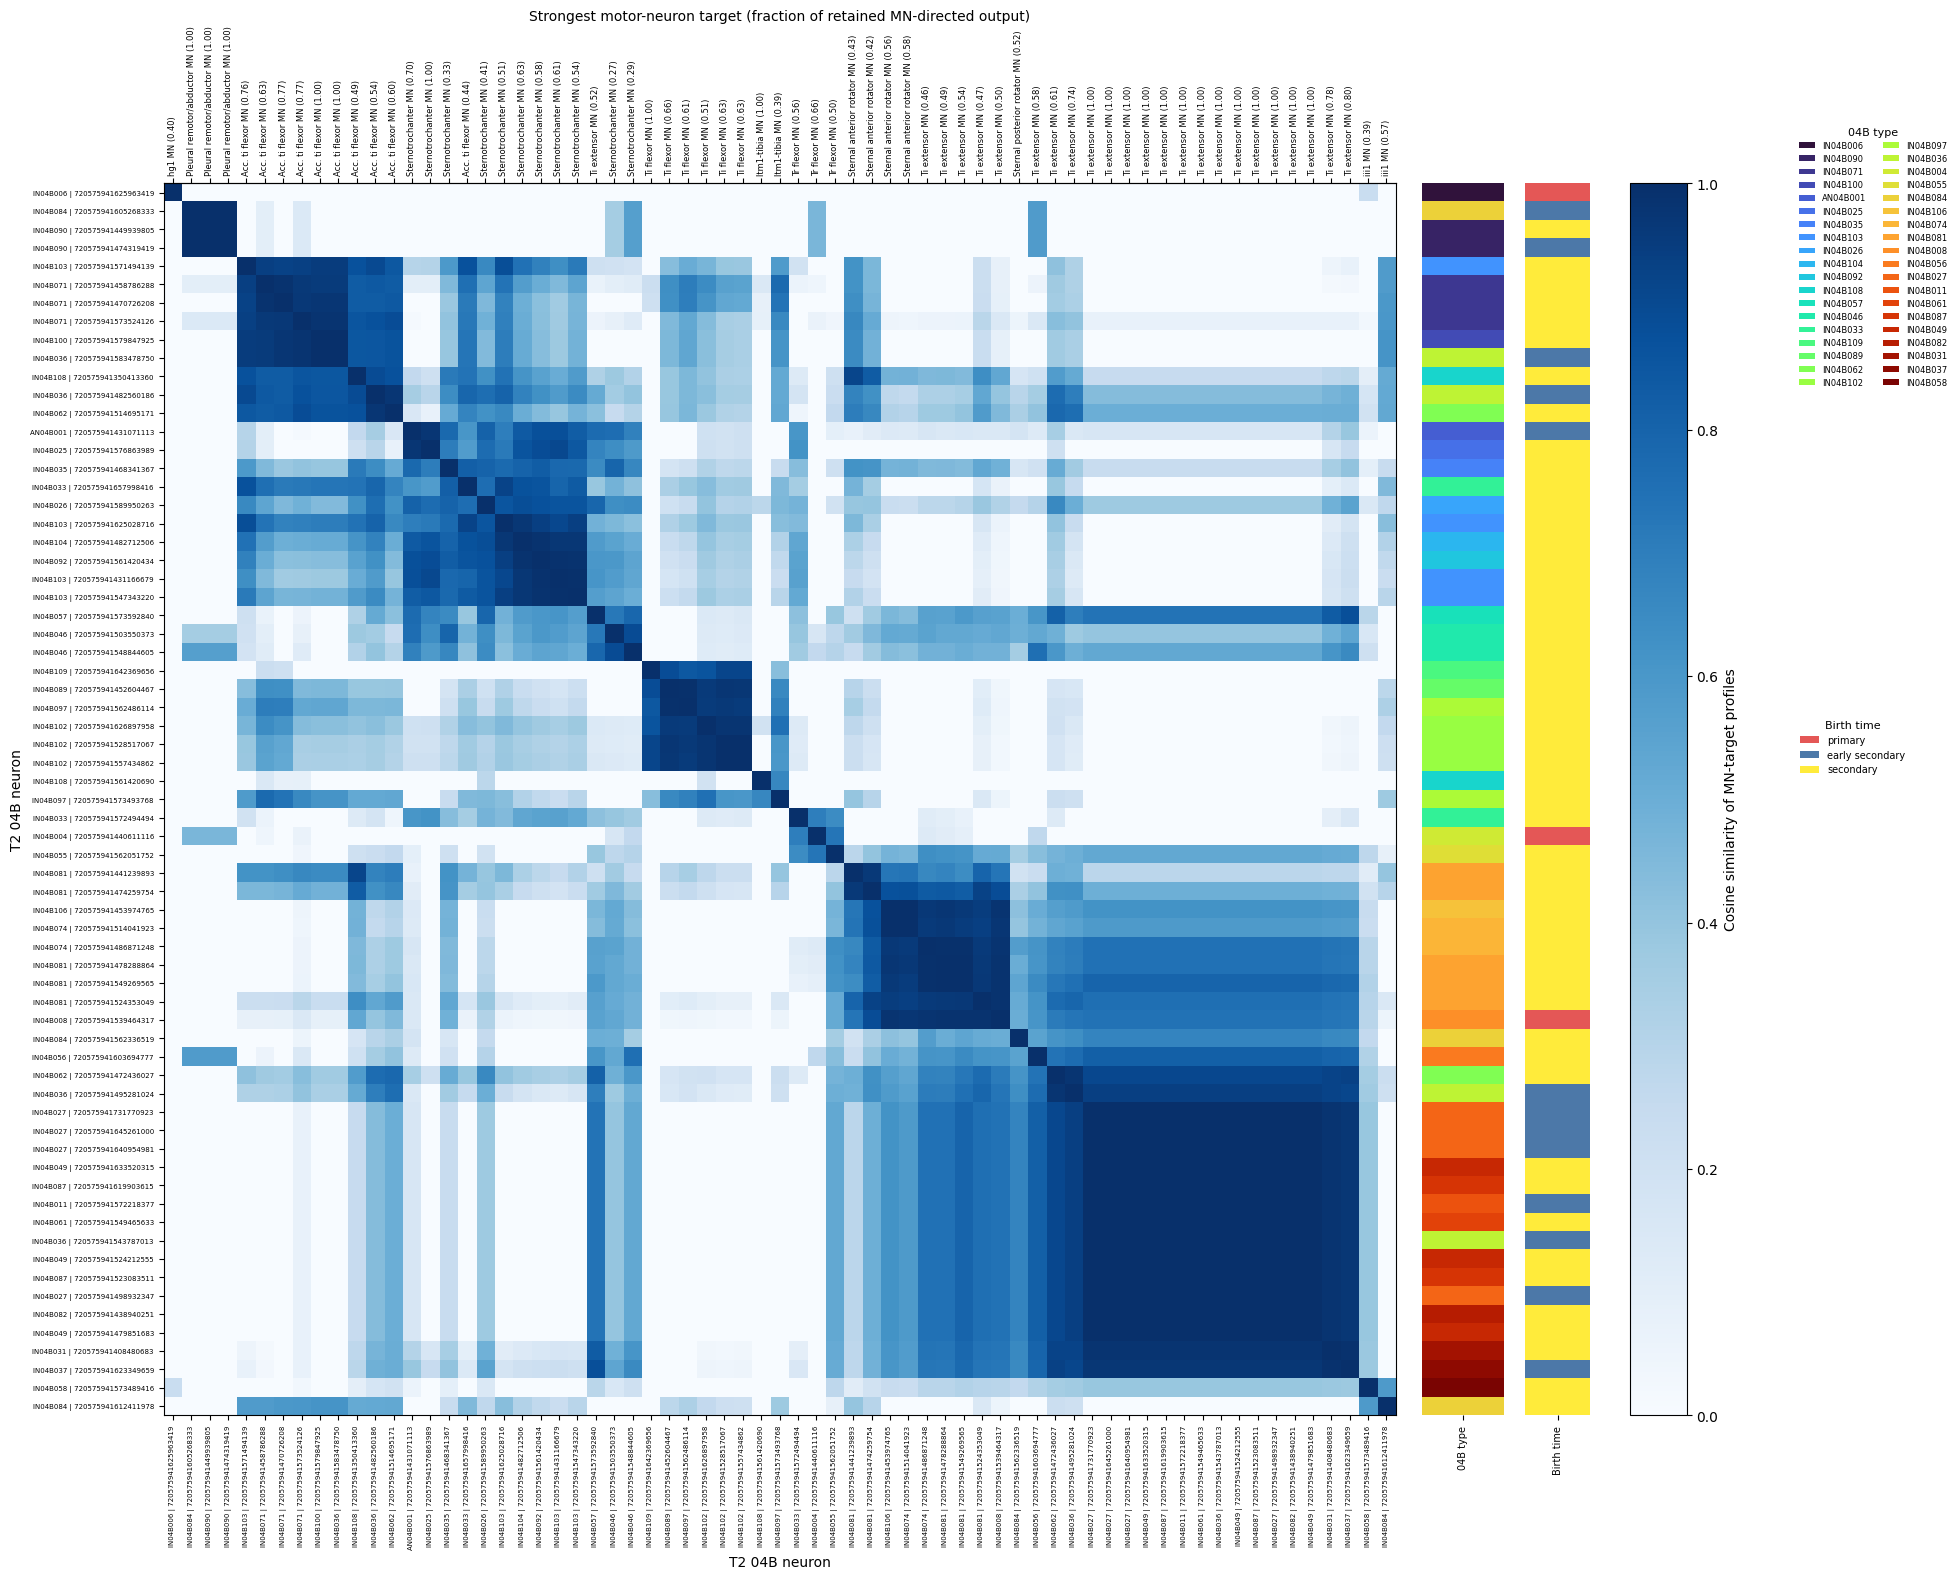

In [15]:
# ============================================================
# STANDALONE 04B MN COSINE FIGURE
# + TOP MN TARGET
# + 04B TYPE GRADIENT
# + BIRTHTIME STRIP
# + LEGENDS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from matplotlib.patches import Patch


print("\n==========================================")
print("04B MN COSINE SIMILARITY")
print("==========================================")


# ============================================================
# SETTINGS
# ============================================================

MIN_SYNAPSES = 10

RESULTS_FILE = (
    r"C:\Users\JHS\Documents\Python\project_folder_4B"
    r"\Faculty_Statement\BANC_04B_T2_connectivity.csv"
)

MANC_METADATA_FILE = (
    r"C:\Users\JHS\Documents\Python\project_folder_4B"
    r"\Faculty_Statement\MANC_T2_04B_metadata.csv"
)

OUTPUT_PDF = (
    r"C:\Users\JHS\Documents\Python\project_folder_4B"
    r"\Faculty_Statement\04B_MN_cosine_type_birthtime.pdf"
)

OUTPUT_PNG = (
    r"C:\Users\JHS\Documents\Python\project_folder_4B"
    r"\Faculty_Statement\04B_MN_cosine_type_birthtime.png"
)


# ============================================================
# 1. LOAD BANC CONNECTIVITY
# ============================================================

print("\nSTEP 1: Loading BANC connectivity...")

results = pd.read_csv(RESULTS_FILE)

print("✓ Loaded connectivity")
print(f"  Rows: {len(results):,}")
print(f"  Source neurons: {results['source_id'].nunique()}")
print(f"  Source types: {results['source_type'].nunique()}")
print(f"  Target types: {results['target_type'].nunique()}")


# ============================================================
# 2. LOAD MANC METADATA
# ============================================================

print("\nSTEP 2: Loading MANC metadata...")

manc_t2_04b = pd.read_csv(MANC_METADATA_FILE)

print("✓ Loaded MANC metadata")
print(f"  Rows: {len(manc_t2_04b)}")


# ============================================================
# 3. KEEP ONLY MOTOR-NEURON TARGETS
# ============================================================

print("\nSTEP 3: Filtering to MN targets...")

mn_df = results[
    results["target_type"]
    .astype(str)
    .str.contains(r"\bMN\b", regex=True, na=False)
].copy()

print(f"✓ MN-directed connections: {len(mn_df):,}")
print(f"  Source neurons: {mn_df['source_id'].nunique()}")
print(f"  MN target types: {mn_df['target_type'].nunique()}")


# ============================================================
# 4. COLLAPSE INDIVIDUAL MN TARGETS INTO MN TYPES
# ============================================================

mn_grouped = (
    mn_df.groupby(
        [
            "source_id",
            "source_type",
            "target_type"
        ],
        as_index=False
    )["synapses"]
    .sum()
)


# ============================================================
# 5. APPLY >=10 SYNAPSE CUTOFF
# ============================================================

before = len(mn_grouped)

mn_grouped = mn_grouped[
    mn_grouped["synapses"] >= MIN_SYNAPSES
].copy()

print(
    f"\n>= {MIN_SYNAPSES} synapse cutoff: "
    f"{len(mn_grouped):,} / {before:,} retained"
)

print(
    f"Source neurons retained: "
    f"{mn_grouped['source_id'].nunique()}"
)


# ============================================================
# 6. BUILD SOURCE × MN TARGET-TYPE MATRIX
# ============================================================

mn_matrix = mn_grouped.pivot_table(
    index=[
        "source_id",
        "source_type"
    ],
    columns="target_type",
    values="synapses",
    aggfunc="sum",
    fill_value=0
)

print(
    f"\nMN matrix: "
    f"{mn_matrix.shape[0]} neurons × "
    f"{mn_matrix.shape[1]} MN target types"
)


# ============================================================
# 7. NORMALIZE WITHIN RETAINED MN-DIRECTED OUTPUT
# ============================================================

mn_normalized = mn_matrix.div(
    mn_matrix.sum(axis=1),
    axis=0
).fillna(0)

mn_normalized = (
    mn_normalized
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

mn_normalized = mn_normalized.loc[
    np.linalg.norm(
        mn_normalized.values,
        axis=1
    ) > 0
]

mn_normalized = mn_normalized.loc[
    :,
    np.linalg.norm(
        mn_normalized.values,
        axis=0
    ) > 0
]


# ============================================================
# 8. CLUSTER NEURONS BY MN TARGET PROFILE
# ============================================================

print("\nSTEP 4: Clustering MN connectivity profiles...")

mn_row_distance = pdist(
    mn_normalized.values,
    metric="cosine"
)

if not np.isfinite(mn_row_distance).all():
    raise ValueError(
        "Non-finite values found in cosine distance."
    )

mn_Z_rows = linkage(
    mn_row_distance,
    method="average"
)

mn_row_order = leaves_list(
    mn_Z_rows
)

print("✓ Row order determined")


# ============================================================
# 9. CALCULATE COSINE SIMILARITY
# ============================================================

mn_cosine = cosine_similarity(
    mn_normalized.values
)

mn_cosine_df = pd.DataFrame(
    mn_cosine,
    index=mn_normalized.index,
    columns=mn_normalized.index
)

mn_cosine_clustered = mn_cosine_df.iloc[
    mn_row_order,
    mn_row_order
]

print(
    f"✓ Cosine matrix: "
    f"{mn_cosine_clustered.shape}"
)


# ============================================================
# 10. SOURCE CELL LABELS
# ============================================================

mn_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type
    in mn_cosine_clustered.index
]


# ============================================================
# 11. STRONGEST MN TARGET FOR EACH SOURCE NEURON
# ============================================================

mn_top_target = mn_normalized.idxmax(
    axis=1
)

mn_top_fraction = mn_normalized.max(
    axis=1
)

mn_top_labels = pd.Series(
    [
        f"{target} ({fraction:.2f})"
        for target, fraction
        in zip(
            mn_top_target,
            mn_top_fraction
        )
    ],
    index=mn_normalized.index
)

mn_top_labels_clustered = mn_top_labels.loc[
    mn_cosine_clustered.index
]

print("✓ Top MN target labels aligned")


# ============================================================
# 12. 04B TYPE ANNOTATION
# ============================================================

type_ordered = [
    source_type
    for source_id, source_type
    in mn_cosine_clustered.index
]

type_mean_position = (
    pd.DataFrame({
        "type": type_ordered,
        "position": np.arange(len(type_ordered))
    })
    .groupby("type")["position"]
    .mean()
    .sort_values()
)

type_categories = (
    type_mean_position
    .index
    .tolist()
)

type_to_number = {
    cell_type: i
    for i, cell_type
    in enumerate(type_categories)
}

type_values = np.array(
    [
        type_to_number[cell_type]
        for cell_type in type_ordered
    ]
).reshape(-1, 1)

type_cmap = plt.get_cmap(
    "turbo",
    max(len(type_categories), 1)
)

print(
    f"✓ 04B type annotation: "
    f"{len(type_categories)} types"
)


# ============================================================
# 13. REBUILD BANC -> MANC MATCH TABLE
# ============================================================

print("\nSTEP 5: Rebuilding BANC → MANC lookup...")

hemilineage = "04B"
side = "left"

hl_df = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system": "hemilineage",
        "cell_type": hemilineage
    }
)

side_df = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system": "side",
        "cell_type": side
    }
)

bundle_neurons = hl_df[
    hl_df["pt_root_id"].isin(
        side_df["pt_root_id"]
    )
].copy()


# ============================================================
# 14. GET MANC MATCH IDS
# ============================================================

manc_id = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system":
        "manc_121_match_id"
    }
)

manc_id_lookup = (
    manc_id[
        [
            "pt_root_id",
            "cell_type"
        ]
    ]
    .rename(
        columns={
            "cell_type":
            "manc_match_id"
        }
    )
)

bundle_neurons = bundle_neurons.merge(
    manc_id_lookup,
    on="pt_root_id",
    how="left"
)


# ============================================================
# 15. CLEAN MANC BODY IDS
# ============================================================

bundle_neurons["manc_bodyid"] = (
    bundle_neurons["manc_match_id"]
    .astype("string")
    .str.replace(
        "id:",
        "",
        regex=False
    )
)

bundle_neurons["manc_bodyid"] = pd.to_numeric(
    bundle_neurons["manc_bodyid"],
    errors="coerce"
).astype("Int64")

manc_t2_04b["bodyid"] = pd.to_numeric(
    manc_t2_04b["bodyid"],
    errors="coerce"
).astype("Int64")


# ============================================================
# 16. KEEP BANC NEURONS MATCHED TO MANC T2 04B
# ============================================================

bundle_T2_04B = bundle_neurons[
    bundle_neurons["manc_bodyid"].isin(
        manc_t2_04b["bodyid"]
    )
].copy()

print(
    f"✓ Matched T2 04B BANC neurons: "
    f"{bundle_T2_04B['pt_root_id'].nunique()}"
)


# ===========================================================
# correct birthtime mapping replaces old 17-20
# ============================================================
# ============================================================
# CORRECT BIRTHTIME MAPPING
#
# IMPORTANT:
# Start from the ACTUAL neurons in the cosine plot.
# Do NOT re-filter BANC by left/right side here.
# ============================================================

print("\n==========================================")
print("MAPPING BIRTHTIME TO PLOTTED NEURONS")
print("==========================================")


# ============================================================
# 1. GET EXACT BANC SOURCE IDS IN COSINE PLOT
# ============================================================

plotted_sources = pd.DataFrame(
    mn_cosine_clustered.index.tolist(),
    columns=[
        "source_id",
        "source_type"
    ]
)

print(
    f"\nPlotted source neurons: "
    f"{plotted_sources['source_id'].nunique()}"
)


# ============================================================
# 2. GET ALL BANC -> MANC MATCH IDS
#
# No side filter.
# ============================================================

manc_id = client.materialize.query_table(
    "codex_annotations",
    filter_equal_dict={
        "classification_system":
        "manc_121_match_id"
    }
)

manc_id_lookup = (
    manc_id[
        [
            "pt_root_id",
            "cell_type"
        ]
    ]
    .drop_duplicates(
        subset="pt_root_id"
    )
    .rename(
        columns={
            "pt_root_id": "source_id",
            "cell_type": "manc_match_id"
        }
    )
)


# ============================================================
# 3. ADD MANC MATCH ID TO EXACT PLOTTED SOURCES
# ============================================================

plotted_sources = plotted_sources.merge(
    manc_id_lookup,
    on="source_id",
    how="left"
)

print(
    f"BANC neurons with MANC match: "
    f"{plotted_sources['manc_match_id'].notna().sum()} / "
    f"{len(plotted_sources)}"
)


# ============================================================
# 4. CLEAN MANC BODY IDS
#
# id:11997 -> 11997
# ============================================================

plotted_sources["manc_bodyid"] = (
    plotted_sources["manc_match_id"]
    .astype("string")
    .str.replace(
        "id:",
        "",
        regex=False
    )
)

plotted_sources["manc_bodyid"] = pd.to_numeric(
    plotted_sources["manc_bodyid"],
    errors="coerce"
).astype("Int64")


# ============================================================
# 5. PREPARE MANC BIRTHTIME TABLE
# ============================================================

manc_t2_04b["bodyid"] = pd.to_numeric(
    manc_t2_04b["bodyid"],
    errors="coerce"
).astype("Int64")

birthtime_lookup = (
    manc_t2_04b[
        [
            "bodyid",
            "birthtime"
        ]
    ]
    .drop_duplicates(
        subset="bodyid"
    )
    .rename(
        columns={
            "bodyid": "manc_bodyid"
        }
    )
)


# ============================================================
# 6. MERGE BIRTHTIME DIRECTLY ONTO PLOTTED NEURONS
# ============================================================

plotted_sources = plotted_sources.merge(
    birthtime_lookup,
    on="manc_bodyid",
    how="left"
)


# ============================================================
# 7. DIAGNOSTIC
# ============================================================

print("\nBirthtimes among EXACT plotted neurons:")

print(
    plotted_sources["birthtime"]
    .value_counts(
        dropna=False
    )
)

print(
    f"\nBirthtime annotated: "
    f"{plotted_sources['birthtime'].notna().sum()} / "
    f"{len(plotted_sources)}"
)

display(
    plotted_sources[
        [
            "source_id",
            "source_type",
            "manc_match_id",
            "manc_bodyid",
            "birthtime"
        ]
    ].head(20)
)


# ============================================================
# 8. BIRTHTIME IS ALREADY IN EXACT COSINE ROW ORDER
#
# plotted_sources was created FROM mn_cosine_clustered.index,
# so DO NOT reorder it again.
# ============================================================

birthtime_ordered = (
    plotted_sources["birthtime"]
    .fillna("unknown")
    .astype(str)
    .tolist()
)

print("\nBirthtime strip order:")

print(
    pd.Series(
        birthtime_ordered
    ).value_counts()
)


# ============================================================
# 9. CONVERT TO CATEGORICAL VALUES FOR PLOTTING
# ============================================================

birth_categories = [
    x for x in [
        "primary",
        "early secondary",
        "secondary",
        "unknown"
    ]
    if x in birthtime_ordered
]

birth_to_number = {
    birthtime: i
    for i, birthtime
    in enumerate(
        birth_categories
    )
}

birth_values = np.array(
    [
        birth_to_number[x]
        for x in birthtime_ordered
    ]
).reshape(-1, 1)


# ============================================================
# 10. BIRTHTIME COLORMAP
# ============================================================


from matplotlib.colors import ListedColormap

birth_color_map = {
    "primary": "#E45756",          # 
    "early secondary": "#4C78A8",  # blue
    "secondary": "#FFEB3B",        # yellow
    "unknown": "#BDBDBD"           # gray
}

birth_colors = [
    birth_color_map[x]
    for x in birth_categories
]

birth_cmap = ListedColormap(
    birth_colors
)



print("\nBirthtime categories used:")
print(birth_categories)



# ============================================================
# 21. VERIFY EXACT ALIGNMENT
# ============================================================

print("\nFirst 10 plotted neurons:")

for i, (
    (source_id, source_type),
    birthtime,
    top_target
) in enumerate(
    zip(
        mn_cosine_clustered.index[:10],
        birthtime_ordered[:10],
        mn_top_labels_clustered.iloc[:10]
    )
):

    print(
        f"{i:2d}: "
        f"{source_type} | "
        f"{source_id} | "
        f"birthtime={birthtime} | "
        f"topMN={top_target}"
    )


# ============================================================
# 22. CREATE FIGURE
#
# cosine | 04B type | birthtime | scale
# ============================================================

print("\nCreating figure...")

fig = plt.figure(
    figsize=(22, 16)
)

gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[
        8,
        0.50,
        0.40,
        0.35
    ],
    wspace=0.18
)


# ============================================================
# 23. COSINE HEATMAP
# ============================================================

ax = fig.add_subplot(
    gs[0, 0]
)

im = ax.imshow(
    mn_cosine_clustered.values,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="equal",
    interpolation="nearest"
)

ax.set_xticks(
    range(len(mn_labels))
)

ax.set_xticklabels(
    mn_labels,
    rotation=90,
    fontsize=5
)

ax.set_yticks(
    range(len(mn_labels))
)

ax.set_yticklabels(
    mn_labels,
    fontsize=5
)

ax.set_xlabel(
    "T2 04B neuron"
)

ax.set_ylabel(
    "T2 04B neuron"
)


# ============================================================
# 24. TOP AXIS = STRONGEST MN TARGET
# ============================================================

ax_top = ax.secondary_xaxis(
    "top"
)

ax_top.set_xticks(
    range(len(mn_labels))
)

ax_top.set_xticklabels(
    mn_top_labels_clustered.values,
    rotation=90,
    fontsize=6
)

ax_top.set_xlabel(
    "Strongest motor-neuron target "
    "(fraction of retained MN-directed output)"
)

ax_top.tick_params(
    axis="x",
    pad=2
)


# ============================================================
# 25. 04B TYPE STRIP
# ============================================================

ax_type = fig.add_subplot(
    gs[0, 1]
)

ax_type.imshow(
    type_values,
    cmap=type_cmap,
    vmin=-0.5,
    vmax=len(type_categories) - 0.5,
    aspect="auto",
    interpolation="nearest"
)

ax_type.set_xticks([0])

ax_type.set_xticklabels(
    ["04B type"],
    rotation=90,
    fontsize=7
)

ax_type.set_yticks([])

for spine in ax_type.spines.values():
    spine.set_visible(False)


# ============================================================
# 26. BIRTHTIME STRIP
# ============================================================

ax_birth = fig.add_subplot(
    gs[0, 2]
)

ax_birth.imshow(
    birth_values,
    cmap=birth_cmap,
    vmin=-0.5,
    vmax=len(birth_categories) - 0.5,
    aspect="auto",
    interpolation="nearest"
)

ax_birth.set_xticks([0])

ax_birth.set_xticklabels(
    ["Birth time"],
    rotation=90,
    fontsize=7
)

ax_birth.set_yticks([])

for spine in ax_birth.spines.values():
    spine.set_visible(False)


# ============================================================
# 27. COSINE COLORBAR
# ============================================================

ax_cbar = fig.add_subplot(
    gs[0, 3]
)

cbar = fig.colorbar(
    im,
    cax=ax_cbar
)

cbar.set_label(
    "Cosine similarity of MN-target profiles"
)


# ============================================================
# 28. ALIGN STRIPS EXACTLY WITH SQUARE COSINE MATRIX
# ============================================================

fig.canvas.draw()

heat_pos = ax.get_position()

type_pos = ax_type.get_position()
birth_pos = ax_birth.get_position()
cbar_pos = ax_cbar.get_position()

ax_type.set_position([
    heat_pos.x1 + 0.012,
    heat_pos.y0,
    type_pos.width,
    heat_pos.height
])

type_final = ax_type.get_position()

ax_birth.set_position([
    type_final.x1 + 0.010,
    heat_pos.y0,
    birth_pos.width,
    heat_pos.height
])

birth_final = ax_birth.get_position()

ax_cbar.set_position([
    birth_final.x1 + 0.018,
    heat_pos.y0,
    cbar_pos.width,
    heat_pos.height
])


# ============================================================
# 29. 04B TYPE LEGEND
# ============================================================

type_handles = [
    Patch(
        facecolor=type_cmap(
            type_to_number[cell_type]
        ),
        edgecolor="none",
        label=cell_type
    )
    for cell_type
    in type_categories
]

fig.legend(
    handles=type_handles,
    title="04B type",
    loc="upper left",
    bbox_to_anchor=(
        0.88,
        0.92
    ),
    fontsize=6,
    title_fontsize=8,
    frameon=False,
    ncol=2
)


# ============================================================
# 30. BIRTHTIME LEGEND
# ============================================================

birth_handles = [
    Patch(
        facecolor=birth_cmap(
            birth_to_number[birthtime]
        ),
        edgecolor="none",
        label=birthtime
    )
    for birthtime
    in birth_categories
]

fig.legend(
    handles=birth_handles,
    title="Birth time",
    loc="upper left",
    bbox_to_anchor=(
        0.88,
        0.55
    ),
    fontsize=7,
    title_fontsize=8,
    frameon=False
)


# ============================================================
# 31. SAVE
# ============================================================

plt.savefig(
    OUTPUT_PDF,
    bbox_inches="tight"
)

plt.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight"
)

print("\n==========================================")
print("COMPLETE")
print("==========================================")

print("✓ MN-only cosine similarity")
print("✓ >=10 synapse cutoff")
print("✓ strongest MN target")
print("✓ 04B type gradient")
print("✓ 04B type legend")
print("✓ birthtime merged onto BANC neurons")
print("✓ birthtime strip")
print("✓ birthtime legend")
print("✓ exact row alignment")

print("\nSaved:")
print(OUTPUT_PDF)
print(OUTPUT_PNG)


# ============================================================
# 32. DISPLAY
# ============================================================

plt.show()

In [11]:
# ============================================================
# DIAGNOSE BIRTHTIME MAPPING
# ============================================================

print("\n==========================================")
print("BIRTHTIME DIAGNOSTIC")
print("==========================================")

# ------------------------------------------------------------
# 1. What birthtimes exist in the original MANC CSV?
# ------------------------------------------------------------

print("\n1. BIRTHTIMES IN ORIGINAL MANC METADATA:")

print(
    manc_t2_04b["birthtime"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 2. What birthtimes survived the BANC-MANC matching?
# ------------------------------------------------------------

print("\n2. BIRTHTIMES IN MATCHED BANC T2 04B NEURONS:")

print(
    bundle_T2_04B["birthtime"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 3. What birthtimes belong specifically to neurons
#    appearing in the MN cosine analysis?
# ------------------------------------------------------------

plotted_source_ids = [
    source_id
    for source_id, source_type
    in mn_cosine_clustered.index
]

plotted_metadata = bundle_T2_04B[
    bundle_T2_04B["pt_root_id"].isin(
        plotted_source_ids
    )
].copy()

print("\n3. BIRTHTIMES AMONG NEURONS IN COSINE PLOT:")

print(
    plotted_metadata["birthtime"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 4. Show each plotted neuron and its birthtime
# ------------------------------------------------------------

print("\n4. EXACT PLOTTED NEURON → BIRTHTIME MAPPING:")

check = pd.DataFrame(
    mn_cosine_clustered.index.tolist(),
    columns=[
        "source_id",
        "source_type"
    ]
)

check = check.merge(
    bundle_T2_04B[
        [
            "pt_root_id",
            "manc_bodyid",
            "birthtime"
        ]
    ].drop_duplicates(
        subset="pt_root_id"
    ),
    left_on="source_id",
    right_on="pt_root_id",
    how="left"
)

display(
    check[
        [
            "source_id",
            "source_type",
            "manc_bodyid",
            "birthtime"
        ]
    ]
)

print("\nBirthtime counts in exact plotted order:")

print(
    check["birthtime"]
    .value_counts(dropna=False)
)


BIRTHTIME DIAGNOSTIC

1. BIRTHTIMES IN ORIGINAL MANC METADATA:
birthtime
secondary          150
early secondary     29
primary              8
Name: count, dtype: int64

2. BIRTHTIMES IN MATCHED BANC T2 04B NEURONS:
birthtime
secondary          61
early secondary    14
primary             3
Name: count, dtype: int64

3. BIRTHTIMES AMONG NEURONS IN COSINE PLOT:
Series([], Name: count, dtype: int64)

4. EXACT PLOTTED NEURON → BIRTHTIME MAPPING:


,source_id,source_type,manc_bodyid,birthtime
0,720575941625963419,IN04B006,<NA>,NaN
1,720575941605268333,IN04B084,<NA>,NaN
2,720575941449939805,IN04B090,<NA>,NaN
3,720575941474319419,IN04B090,<NA>,NaN
4,720575941571494139,IN04B103,<NA>,NaN
...,...,...,...,...
62,720575941479851683,IN04B049,<NA>,NaN
63,720575941408480683,IN04B031,<NA>,NaN
64,720575941623349659,IN04B037,<NA>,NaN
65,720575941573489416,IN04B058,<NA>,NaN



Birthtime counts in exact plotted order:
birthtime
NaN    67
Name: count, dtype: int64
